In [1]:
import numpy as np
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
import pandas as pd


ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 14
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300


In [3]:
# read in GEM data from Huanyuan Zhang's v20260317 'GEM_biomass_GPP' spreadsheet
# units for NPP columns are MgC/ha/year
cols = [
    'Plot_code', 'NPP_all_stem', 'NPP_leaf', 'NPP_flower',
    'NPP_fruit', 'NPP_seed', 'NPP_coarseroot', 'NPP_fineroots',
    'LAI', 'CUE'
]

df = pd.read_csv(
    '/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/GEM/from_HZ_GEM_biomass_GPP_v20260317.csv',
    sep=',',
    usecols=cols,
    na_values=['Not measured', 'Not mentioned', 'Bad data']
)

# Cast numeric columns to float
numeric_cols = [c for c in cols if c != 'Plot_code']
df[numeric_cols] = df[numeric_cols].astype(float)

print(df)

   Plot_code  NPP_all_stem  NPP_leaf  NPP_flower  NPP_fruit  NPP_seed  \
0     ALP-01          4.30      2.68      0.0900     0.2900       NaN   
1     ALP-30          2.94      4.05      0.0900     0.3100       NaN   
2     KEN-01          4.12      2.91      0.2400     0.4000      0.07   
3     KEN-02          2.56      2.22      0.1200     0.1200      0.07   
4     CAX-03          2.55      2.07      0.3038     0.1164       NaN   
5     CAX-06          3.20      3.68      0.1800     0.2400       NaN   
6     CAX-08          2.92      2.90      0.1800     1.1200       NaN   
7     TAM-05          2.64      4.03      0.1600     0.2600       NaN   
8     TAM-06          2.64      3.71      0.1500     0.4000       NaN   
9     AGP-01          3.40       NaN         NaN        NaN       NaN   
10    AGP-02          3.80       NaN         NaN        NaN       NaN   
11    ZAR-01          1.30       NaN         NaN        NaN       NaN   
12    JEN-11           NaN       NaN         NaN   

In [4]:
np.nanmean(df.CUE)

0.3854545454545455

In [5]:
np.nanstd(df.CUE)

0.06155022138113002

In [6]:
np.nanmean(df.CUE.values[0:9])

0.3788888888888889

In [7]:
np.nanstd(df.CUE[0:9])

0.05606433694019051

In [4]:
gem_npp_seed=df.NPP_flower.fillna(0).values+df.NPP_fruit.fillna(0).values+df.NPP_seed.fillna(0).values
print(gem_npp_seed[0:9])

[0.38   0.4    0.71   0.31   0.4202 0.42   1.3    0.42   0.55  ]


In [5]:
gem_npp_froot=df.NPP_fineroots.values
gem_npp_croot=df.NPP_coarseroot.values
gem_npp_stem=df.NPP_all_stem.values
gem_npp_leaf=df.NPP_leaf.values
gem_npp_seed=df.NPP_flower.fillna(0).values+df.NPP_fruit.fillna(0).values+df.NPP_seed.fillna(0).values


In [62]:
print(gem_npp_froot[0:9])
print(gem_npp_croot[0:9])
print(gem_npp_stem[0:9])
print(gem_npp_leaf[0:9])
print(gem_npp_seed[0:9])
print(df.Plot_code.values[0:9])

[3.02 3.5  4.04 3.04 3.89 3.68 6.41 4.54 2.11]
[0.53 0.58 0.57 0.44 0.54 0.55 0.53 0.46 0.58]
[4.3  2.94 4.12 2.56 2.55 3.2  2.92 2.64 2.64]
[2.68 4.05 2.91 2.22 2.07 3.68 2.9  4.03 3.71]
[0.38   0.4    0.71   0.31   0.4202 0.42   1.3    0.42   0.55  ]
['ALP-01' 'ALP-30' 'KEN-01' 'KEN-02' 'CAX-03' 'CAX-06' 'CAX-08' 'TAM-05'
 'TAM-06']


/tmp/ipykernel_245512/3374402643.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


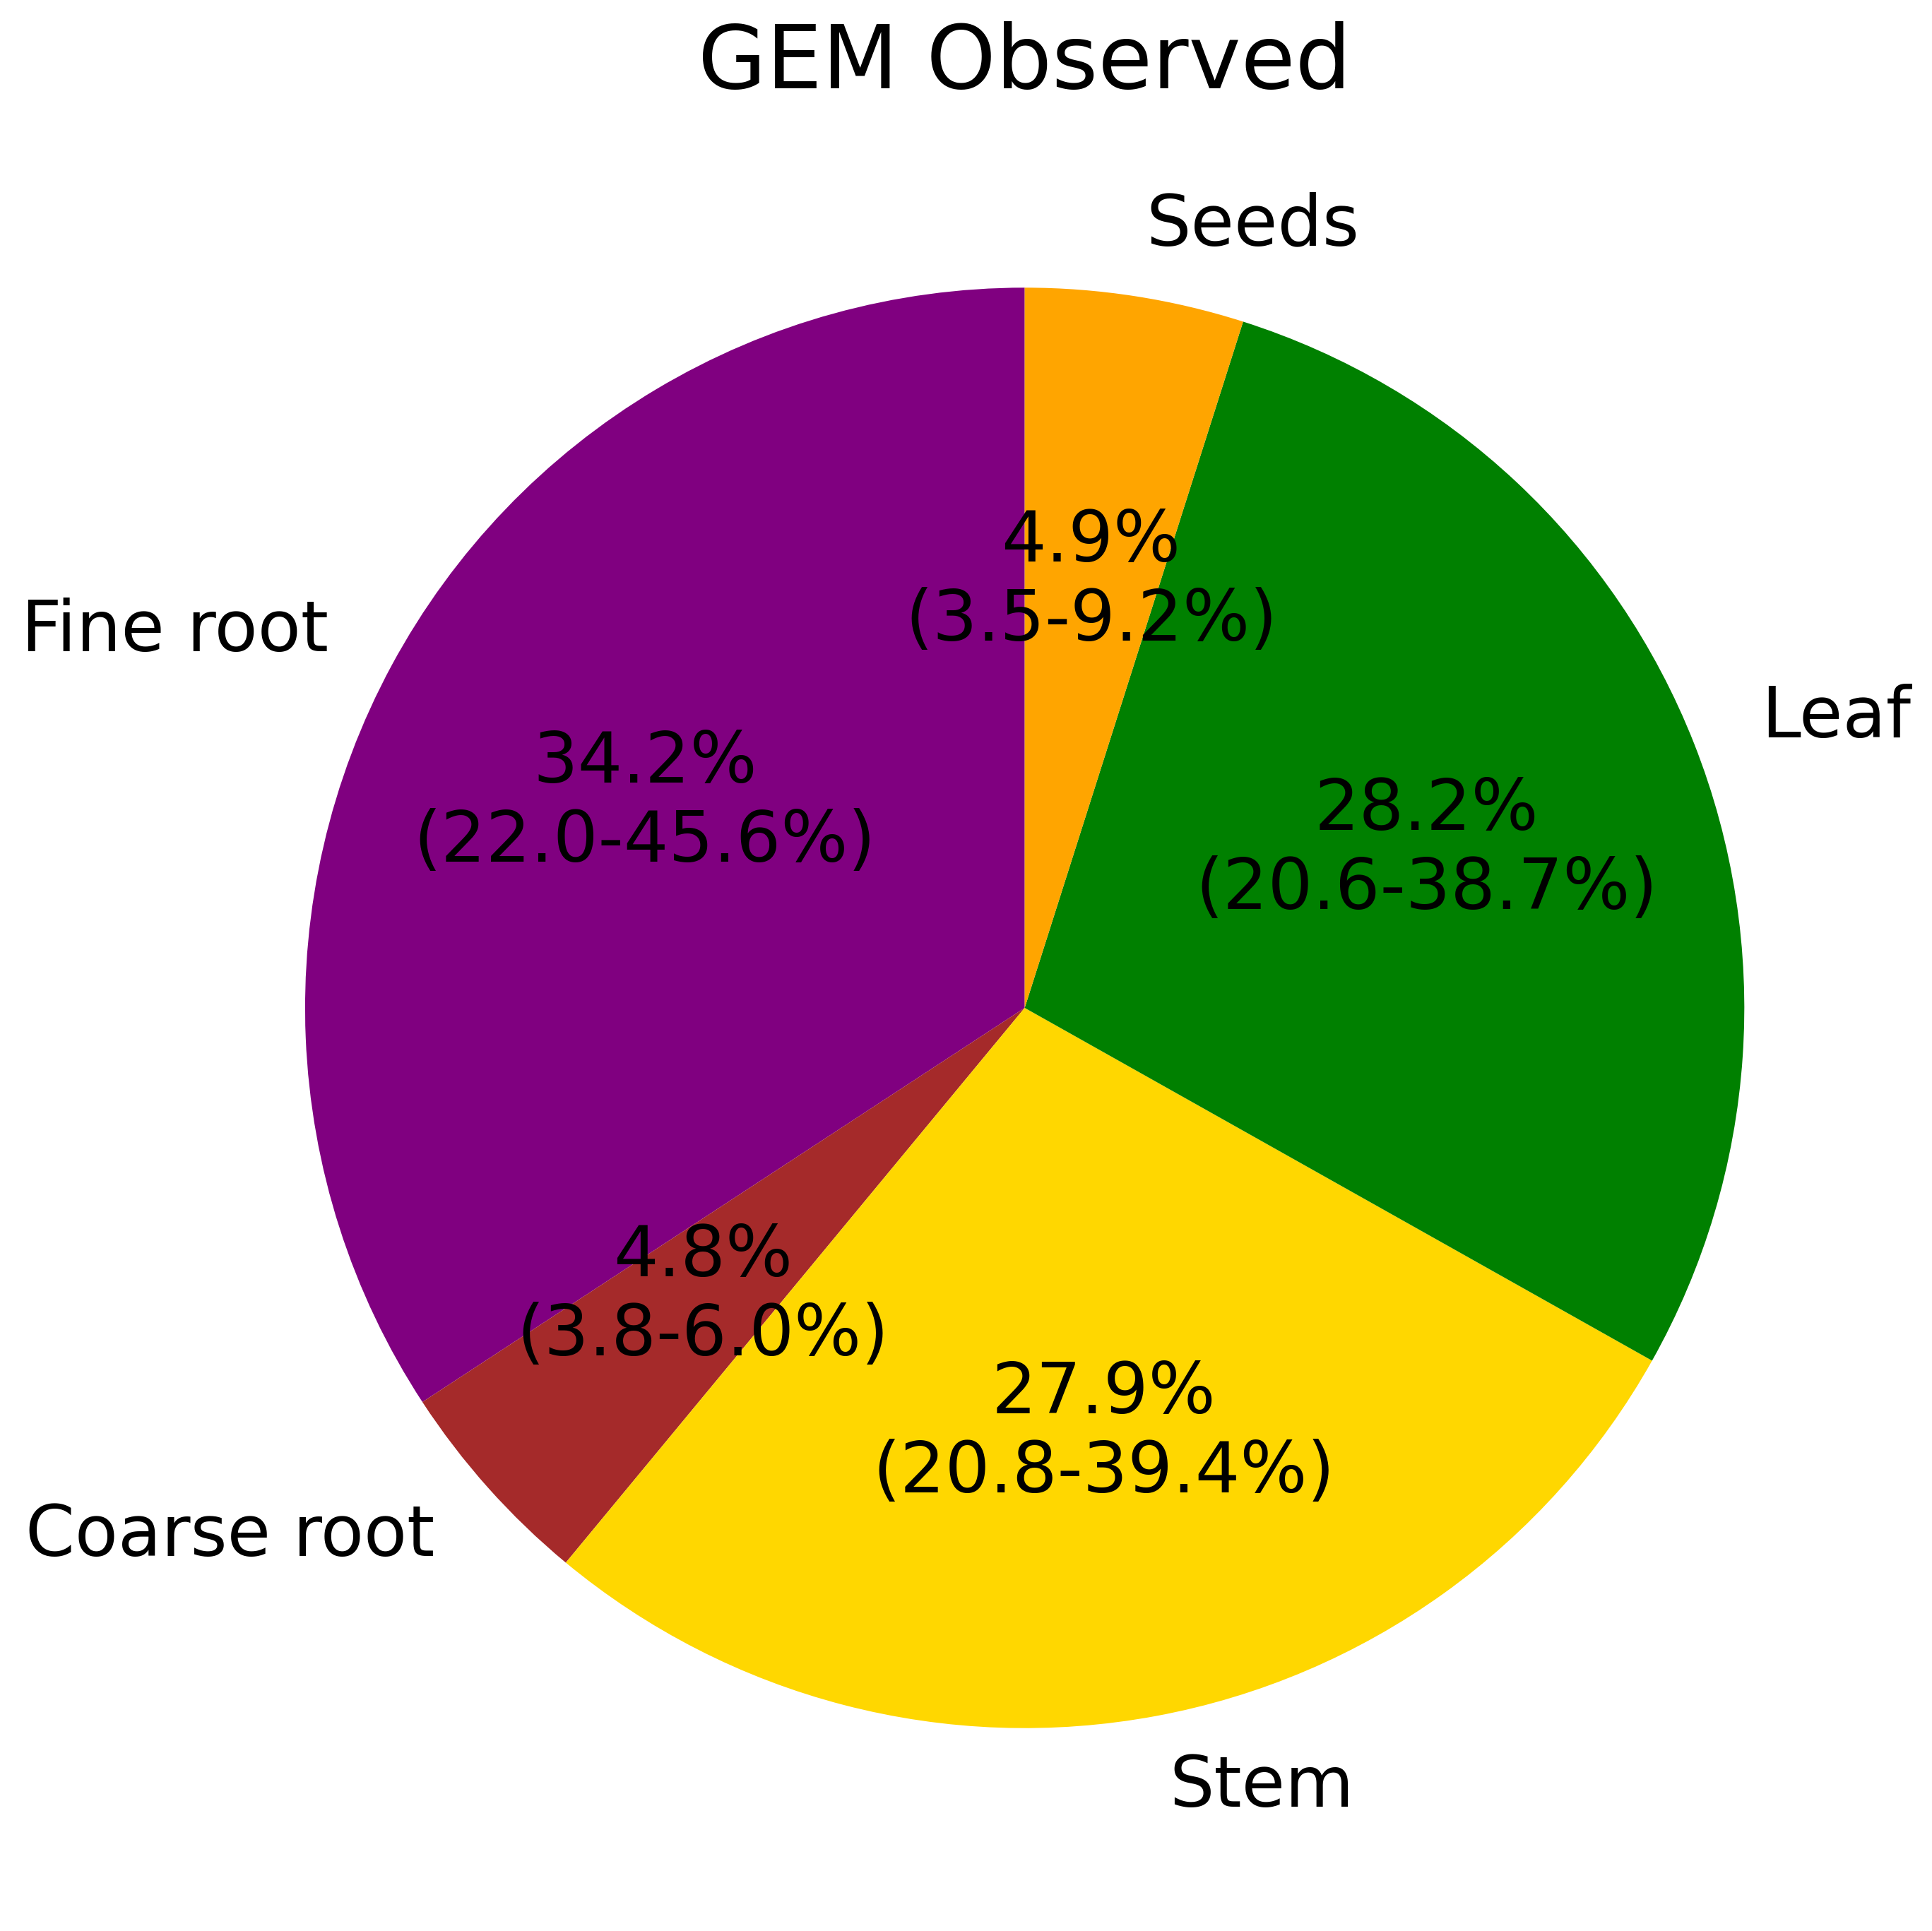

In [63]:
# Calculate means for allocation: ALP, KEN, CAX, TAM
alloc = [
    np.nanmean(gem_npp_froot[0:9]),
    np.nanmean(gem_npp_croot[0:9]),
    np.nanmean(gem_npp_stem[0:9]),
    np.nanmean(gem_npp_leaf[0:9]),
    np.nanmean(gem_npp_seed[0:9])
]

# Store the raw data arrays for min/max calculation
raw_data = [gem_npp_froot[0:9], gem_npp_croot[0:9], gem_npp_stem[0:9], gem_npp_leaf[0:9], gem_npp_seed[0:9]]

# Calculate total NPP for each site to get percentages
total_npp = np.array([
    gem_npp_froot[i] + gem_npp_croot[i] + 
    gem_npp_stem[i] + gem_npp_leaf[i] + gem_npp_seed[i] 
    for i in range(len(gem_npp_froot[0:9]))
])

# Calculate percentage ranges for each component
pct_ranges = []
for data_array in raw_data:
    percentages = (data_array / total_npp) * 100
    pct_ranges.append((np.nanmin(percentages), np.nanmax(percentages)))

labels = ['Fine root', 'Coarse root', 'Stem', 'Leaf', 'Seeds']
colors = ['purple', 'brown', 'gold', 'green', 'orange']

# Create custom autopct function to show mean with (min-max) range
def make_autopct(pct_ranges):
    def my_autopct(pct, idx=[0]):
        min_pct, max_pct = pct_ranges[idx[0]]
        idx[0] += 1
        return f'{pct:.1f}%\n({min_pct:.1f}-{max_pct:.1f}%)'
    return my_autopct

# Create figure with specific size for better readability
fig, ax = plt.subplots(figsize=(9, 9))

# Create the pie chart with enhanced styling
wedges, texts, autotexts = ax.pie(
    alloc, 
    labels=labels, 
    colors=colors, 
    autopct=make_autopct(pct_ranges),
    startangle=90,
    textprops={'fontsize': 24}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(24)

#plt.suptitle('GEM Observed Carbon Allocation (ALP, CAX, KEN, TAM)',fontsize=30)
plt.title('GEM Observed',fontsize=30)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [12]:
print(df.Plot_code.values[0:2],df.Plot_code.values[4:7])

['ALP-01' 'ALP-30'] ['CAX-03' 'CAX-06' 'CAX-08']


/tmp/ipykernel_245512/1334442398.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


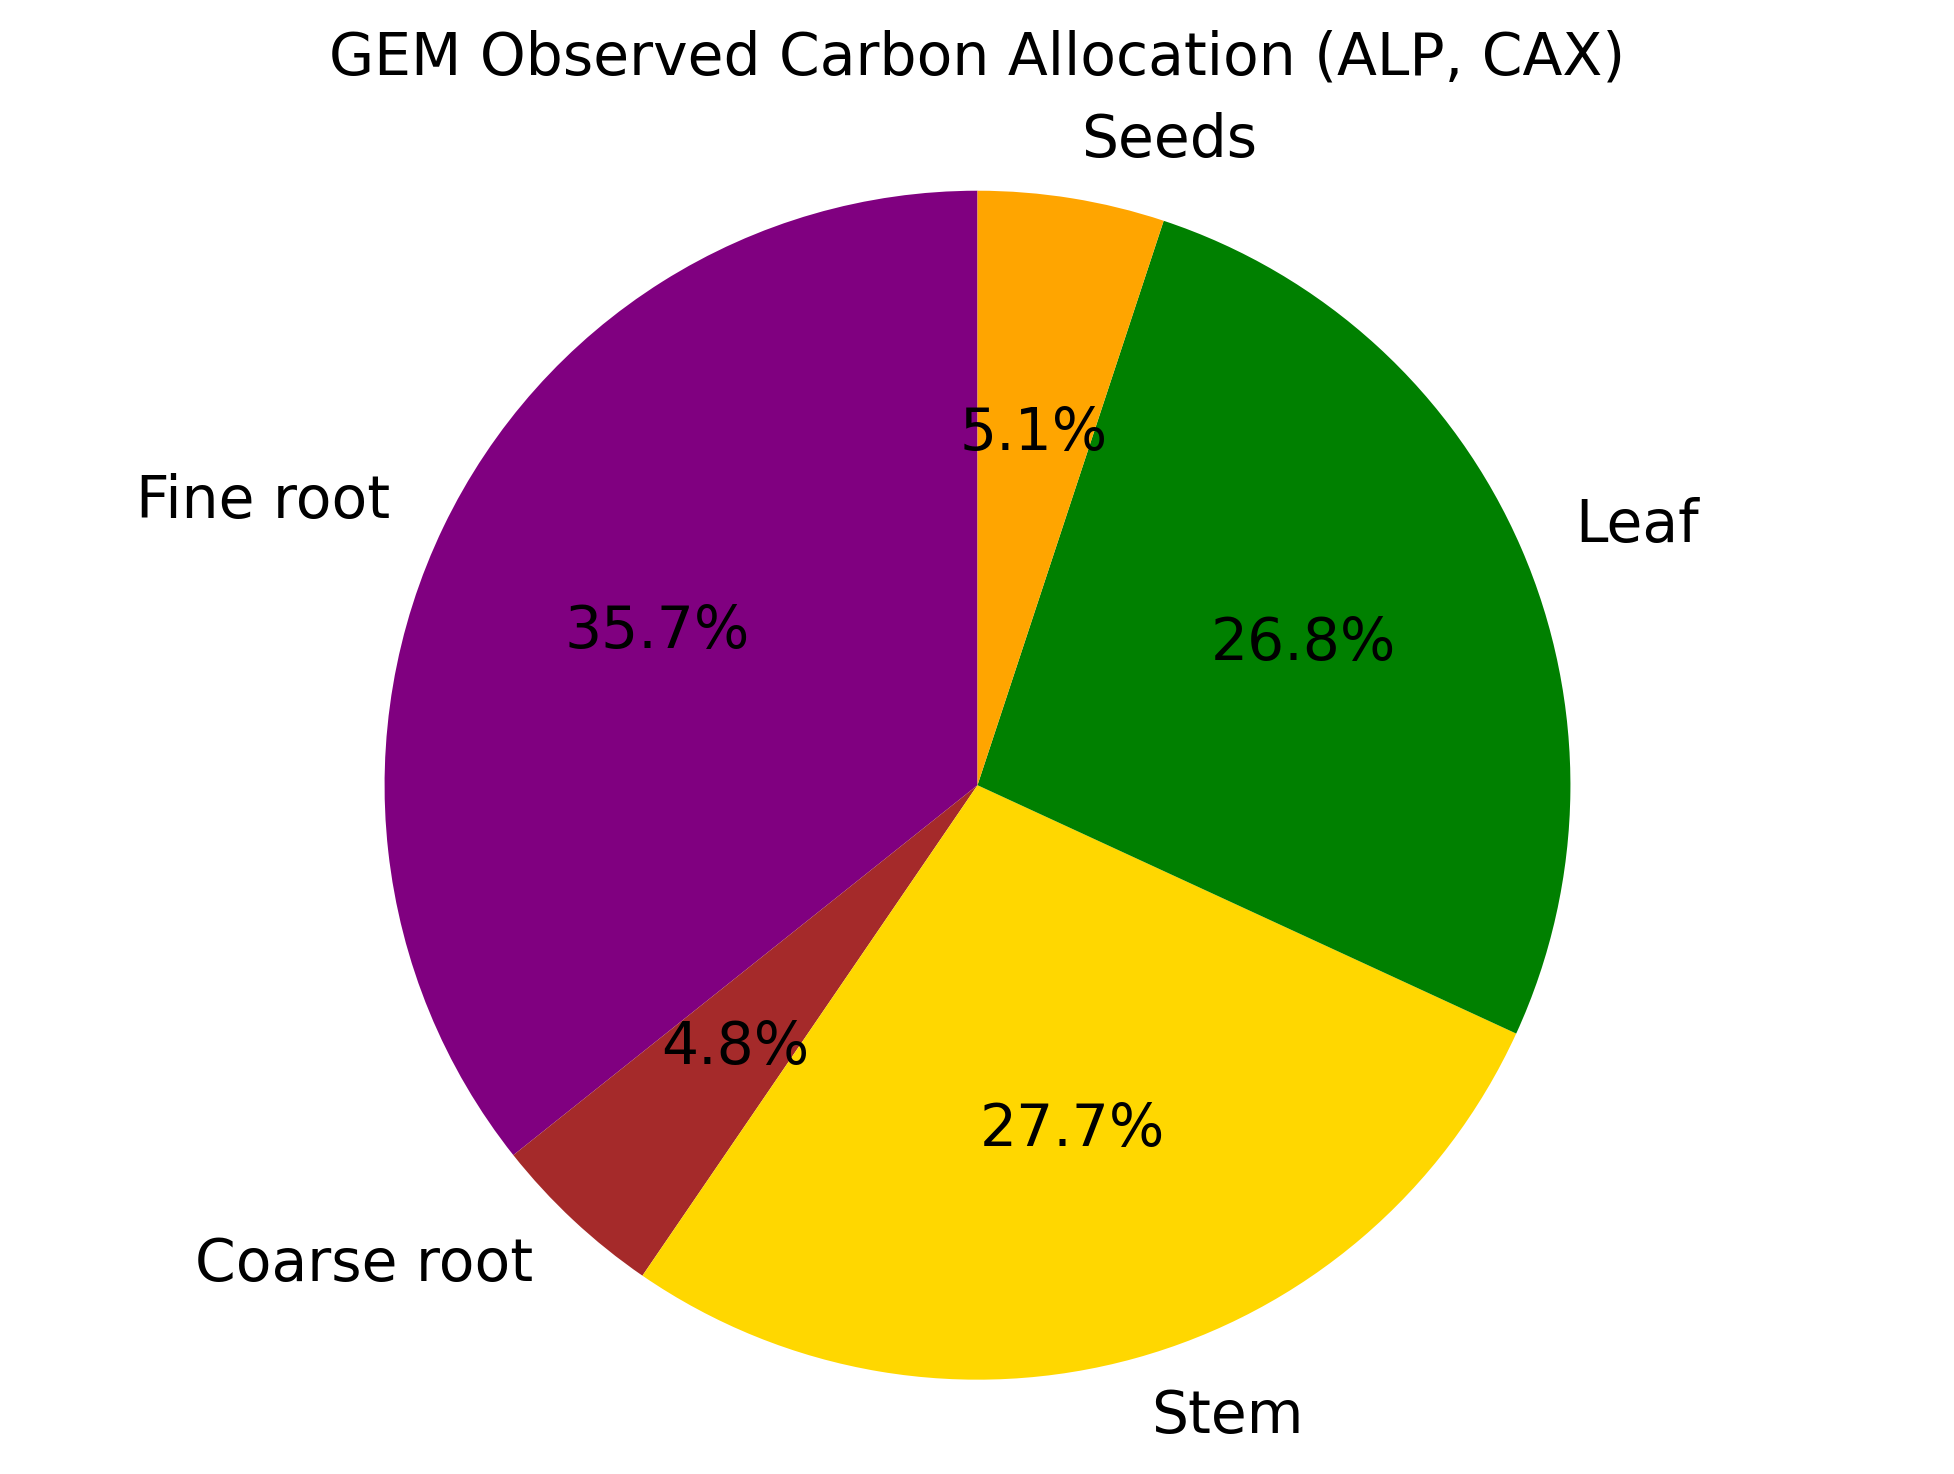

In [65]:
# Calculate means for allocation: ALP & CAX, excluding KEN
alloc = [
    np.nanmean(np.concatenate([gem_npp_froot[0:2],gem_npp_froot[4:7]])),
    np.nanmean(np.concatenate([gem_npp_croot[0:2],gem_npp_croot[4:7]])),
    np.nanmean(np.concatenate([gem_npp_stem[0:2],gem_npp_stem[4:7]])),
    np.nanmean(np.concatenate([gem_npp_leaf[0:2],gem_npp_leaf[4:7]])),
    np.nanmean(np.concatenate([gem_npp_seed[0:2],gem_npp_seed[4:7]]))
]

labels = ['Fine root', 'Coarse root', 'Stem', 'Leaf', 'Seeds']
colors = ['purple', 'brown', 'gold', 'green', 'orange']

plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.suptitle('GEM Observed Carbon Allocation (ALP, CAX)',fontsize='14')

plt.axis('equal')
plt.tight_layout()
plt.show()

In [14]:
print(df.Plot_code.values)

['ALP-01' 'ALP-30' 'KEN-01' 'KEN-02' 'CAX-03' 'CAX-06' 'CAX-08' 'TAM-05'
 'TAM-06' 'AGP-01' 'AGP-02' 'ZAR-01' 'JEN-11' 'JEN-12' 'MAN-05' 'TAP-04']


In [15]:
print(df.Plot_code.values[0:2])

['ALP-01' 'ALP-30']


/tmp/ipykernel_245512/502499721.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


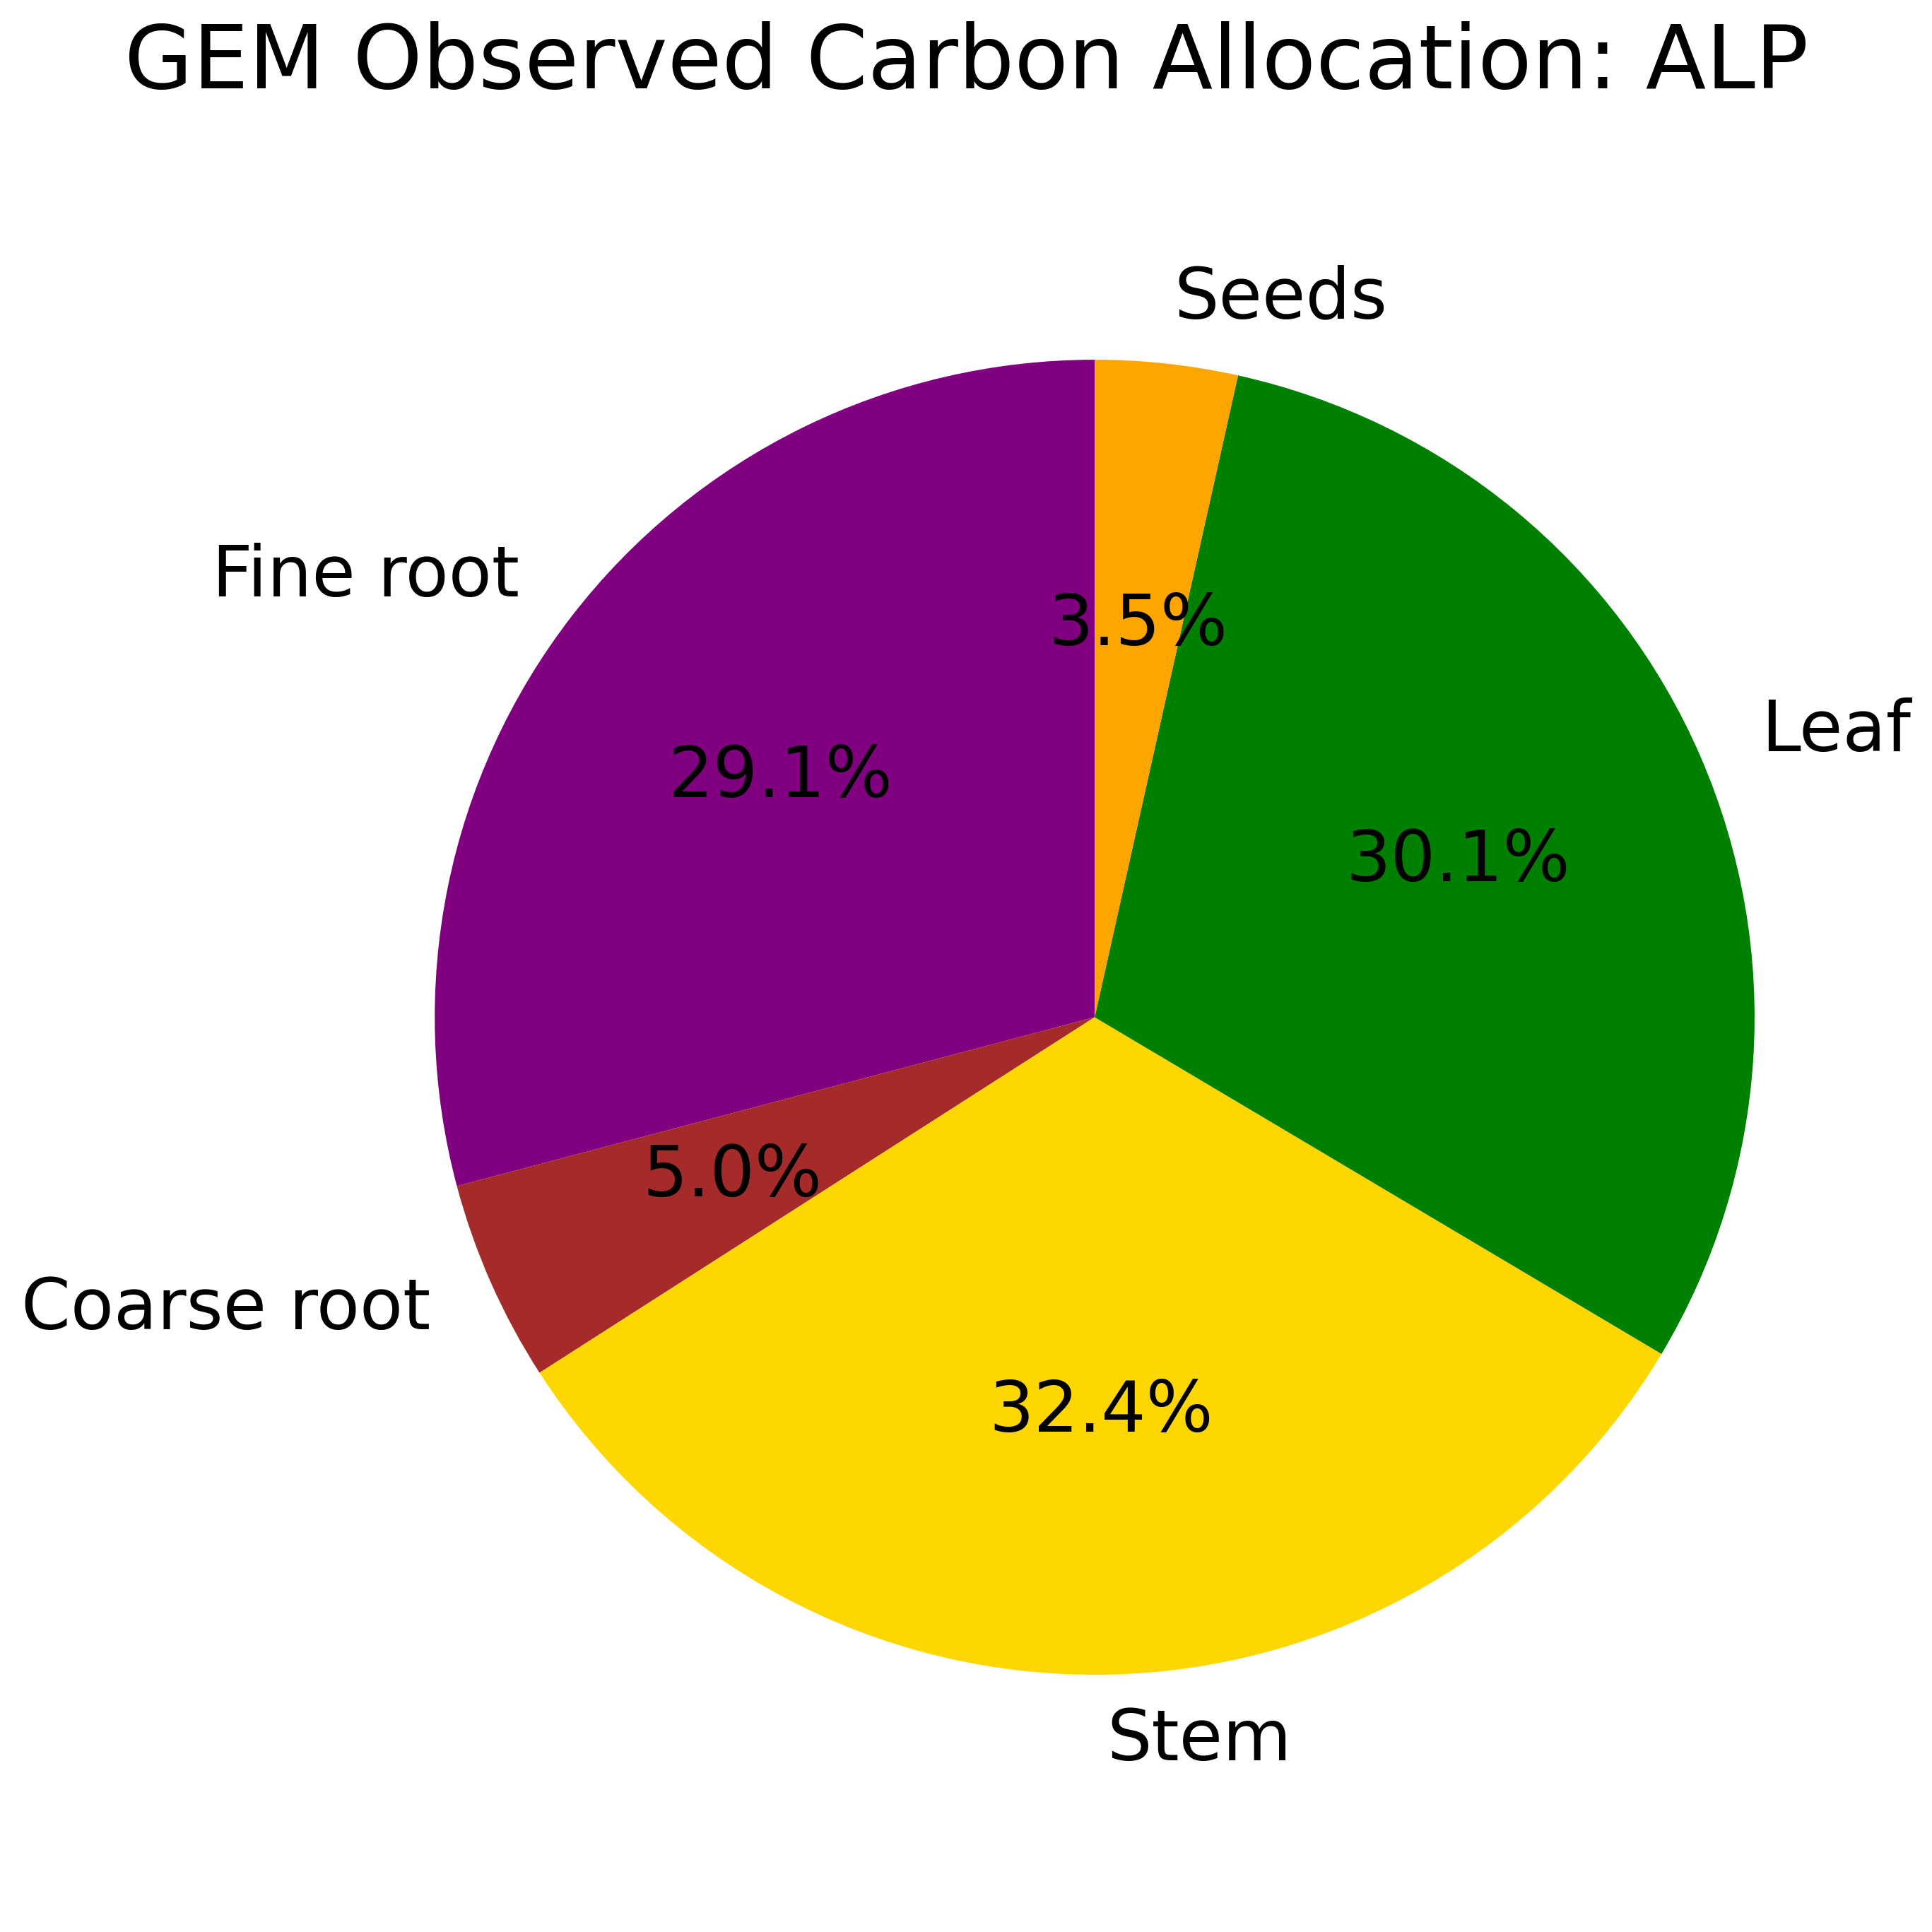

In [67]:
# Calculate means for allocation: ALP only
alloc = [
    np.nanmean(gem_npp_froot[0:2]),
    np.nanmean(gem_npp_croot[0:2]),
    np.nanmean(gem_npp_stem[0:2]),
    np.nanmean(gem_npp_leaf[0:2]),
    np.nanmean(gem_npp_seed[0:2])
]


labels = ['Fine root', 'Coarse root', 'Stem', 'Leaf', 'Seeds']
colors = ['purple', 'brown', 'gold', 'green', 'orange']


# Create figure with specific size for better readability
fig, ax = plt.subplots(figsize=(9, 9))

plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})
plt.suptitle('GEM Observed Carbon Allocation: ALP',fontsize='30')

plt.axis('equal')
plt.tight_layout()
plt.show()

In [17]:
print(df.Plot_code.values[2:4])

['KEN-01' 'KEN-02']


/tmp/ipykernel_245512/1798745751.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


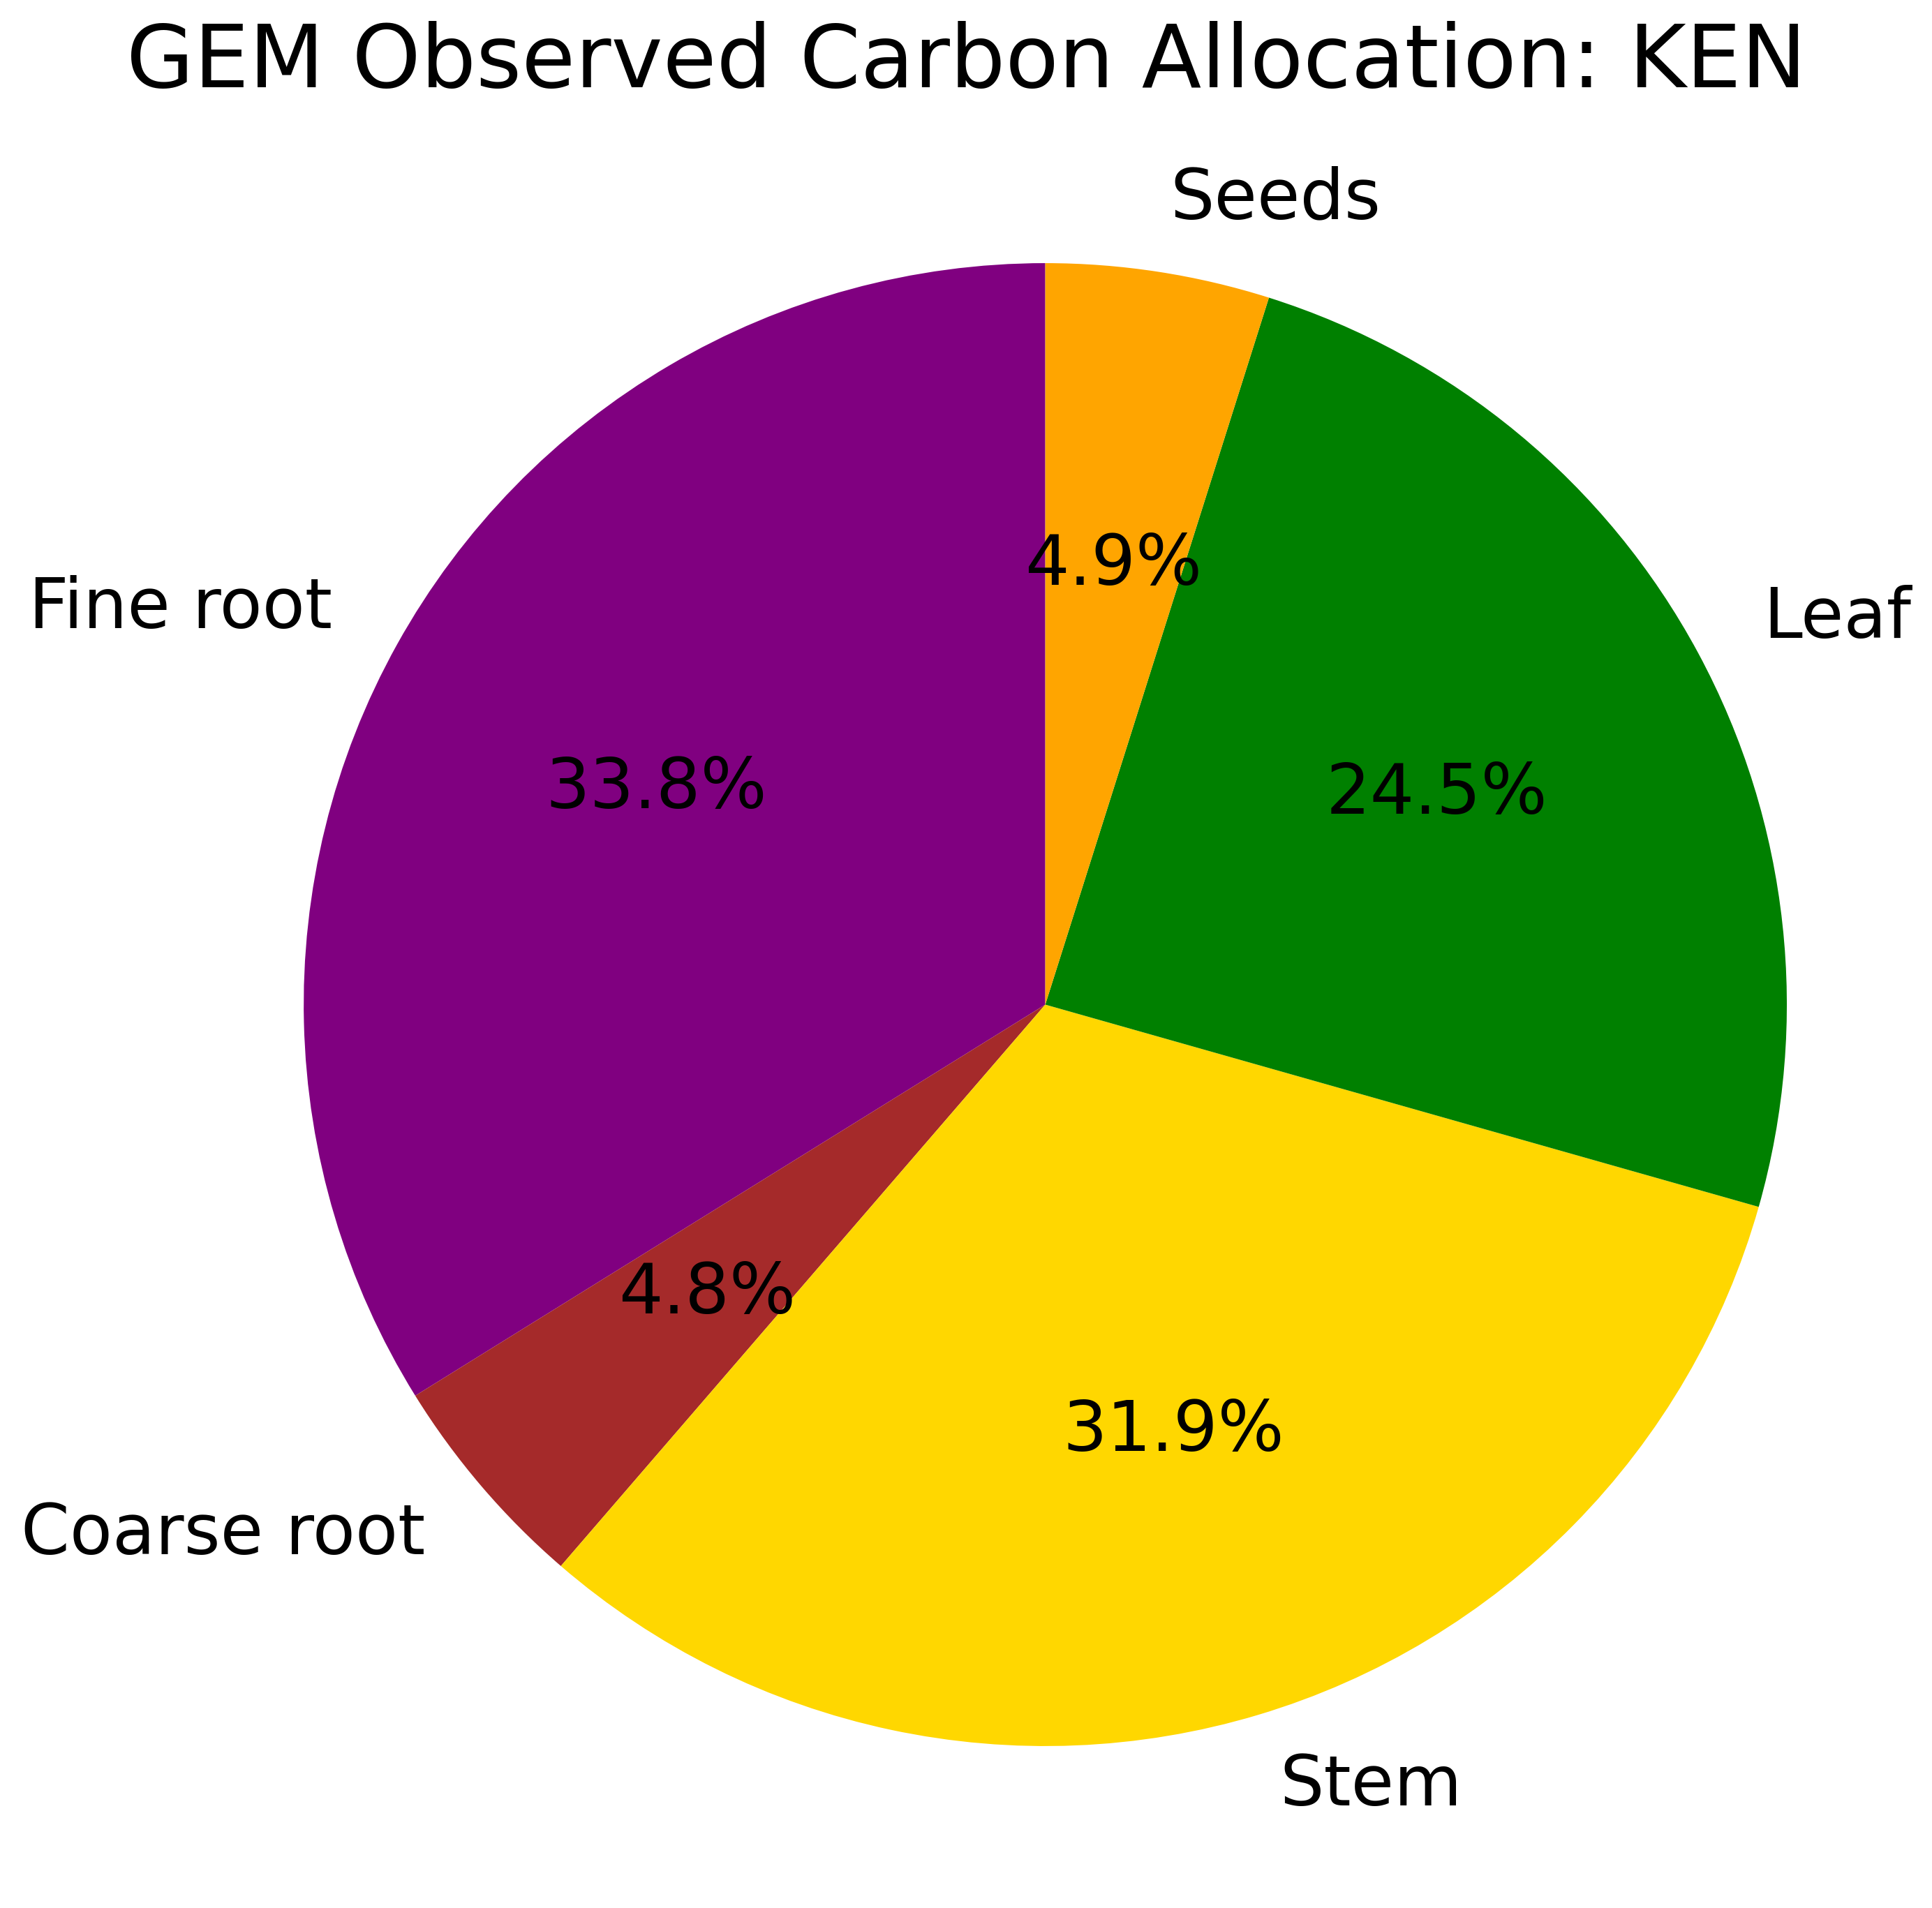

In [68]:
# Calculate means for allocation: KEN only
alloc = [
    np.nanmean(gem_npp_froot[2:4]),
    np.nanmean(gem_npp_croot[2:4]),
    np.nanmean(gem_npp_stem[2:4]),
    np.nanmean(gem_npp_leaf[2:4]),
    np.nanmean(gem_npp_seed[2:4])
]

# Create figure with specific size for better readability
fig, ax = plt.subplots(figsize=(9, 9))

plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})
plt.suptitle('GEM Observed Carbon Allocation: KEN',fontsize='30')

plt.axis('equal')
plt.tight_layout()
plt.show()

In [19]:
print(df.Plot_code.values[4:7])

['CAX-03' 'CAX-06' 'CAX-08']


/tmp/ipykernel_245512/1214985199.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


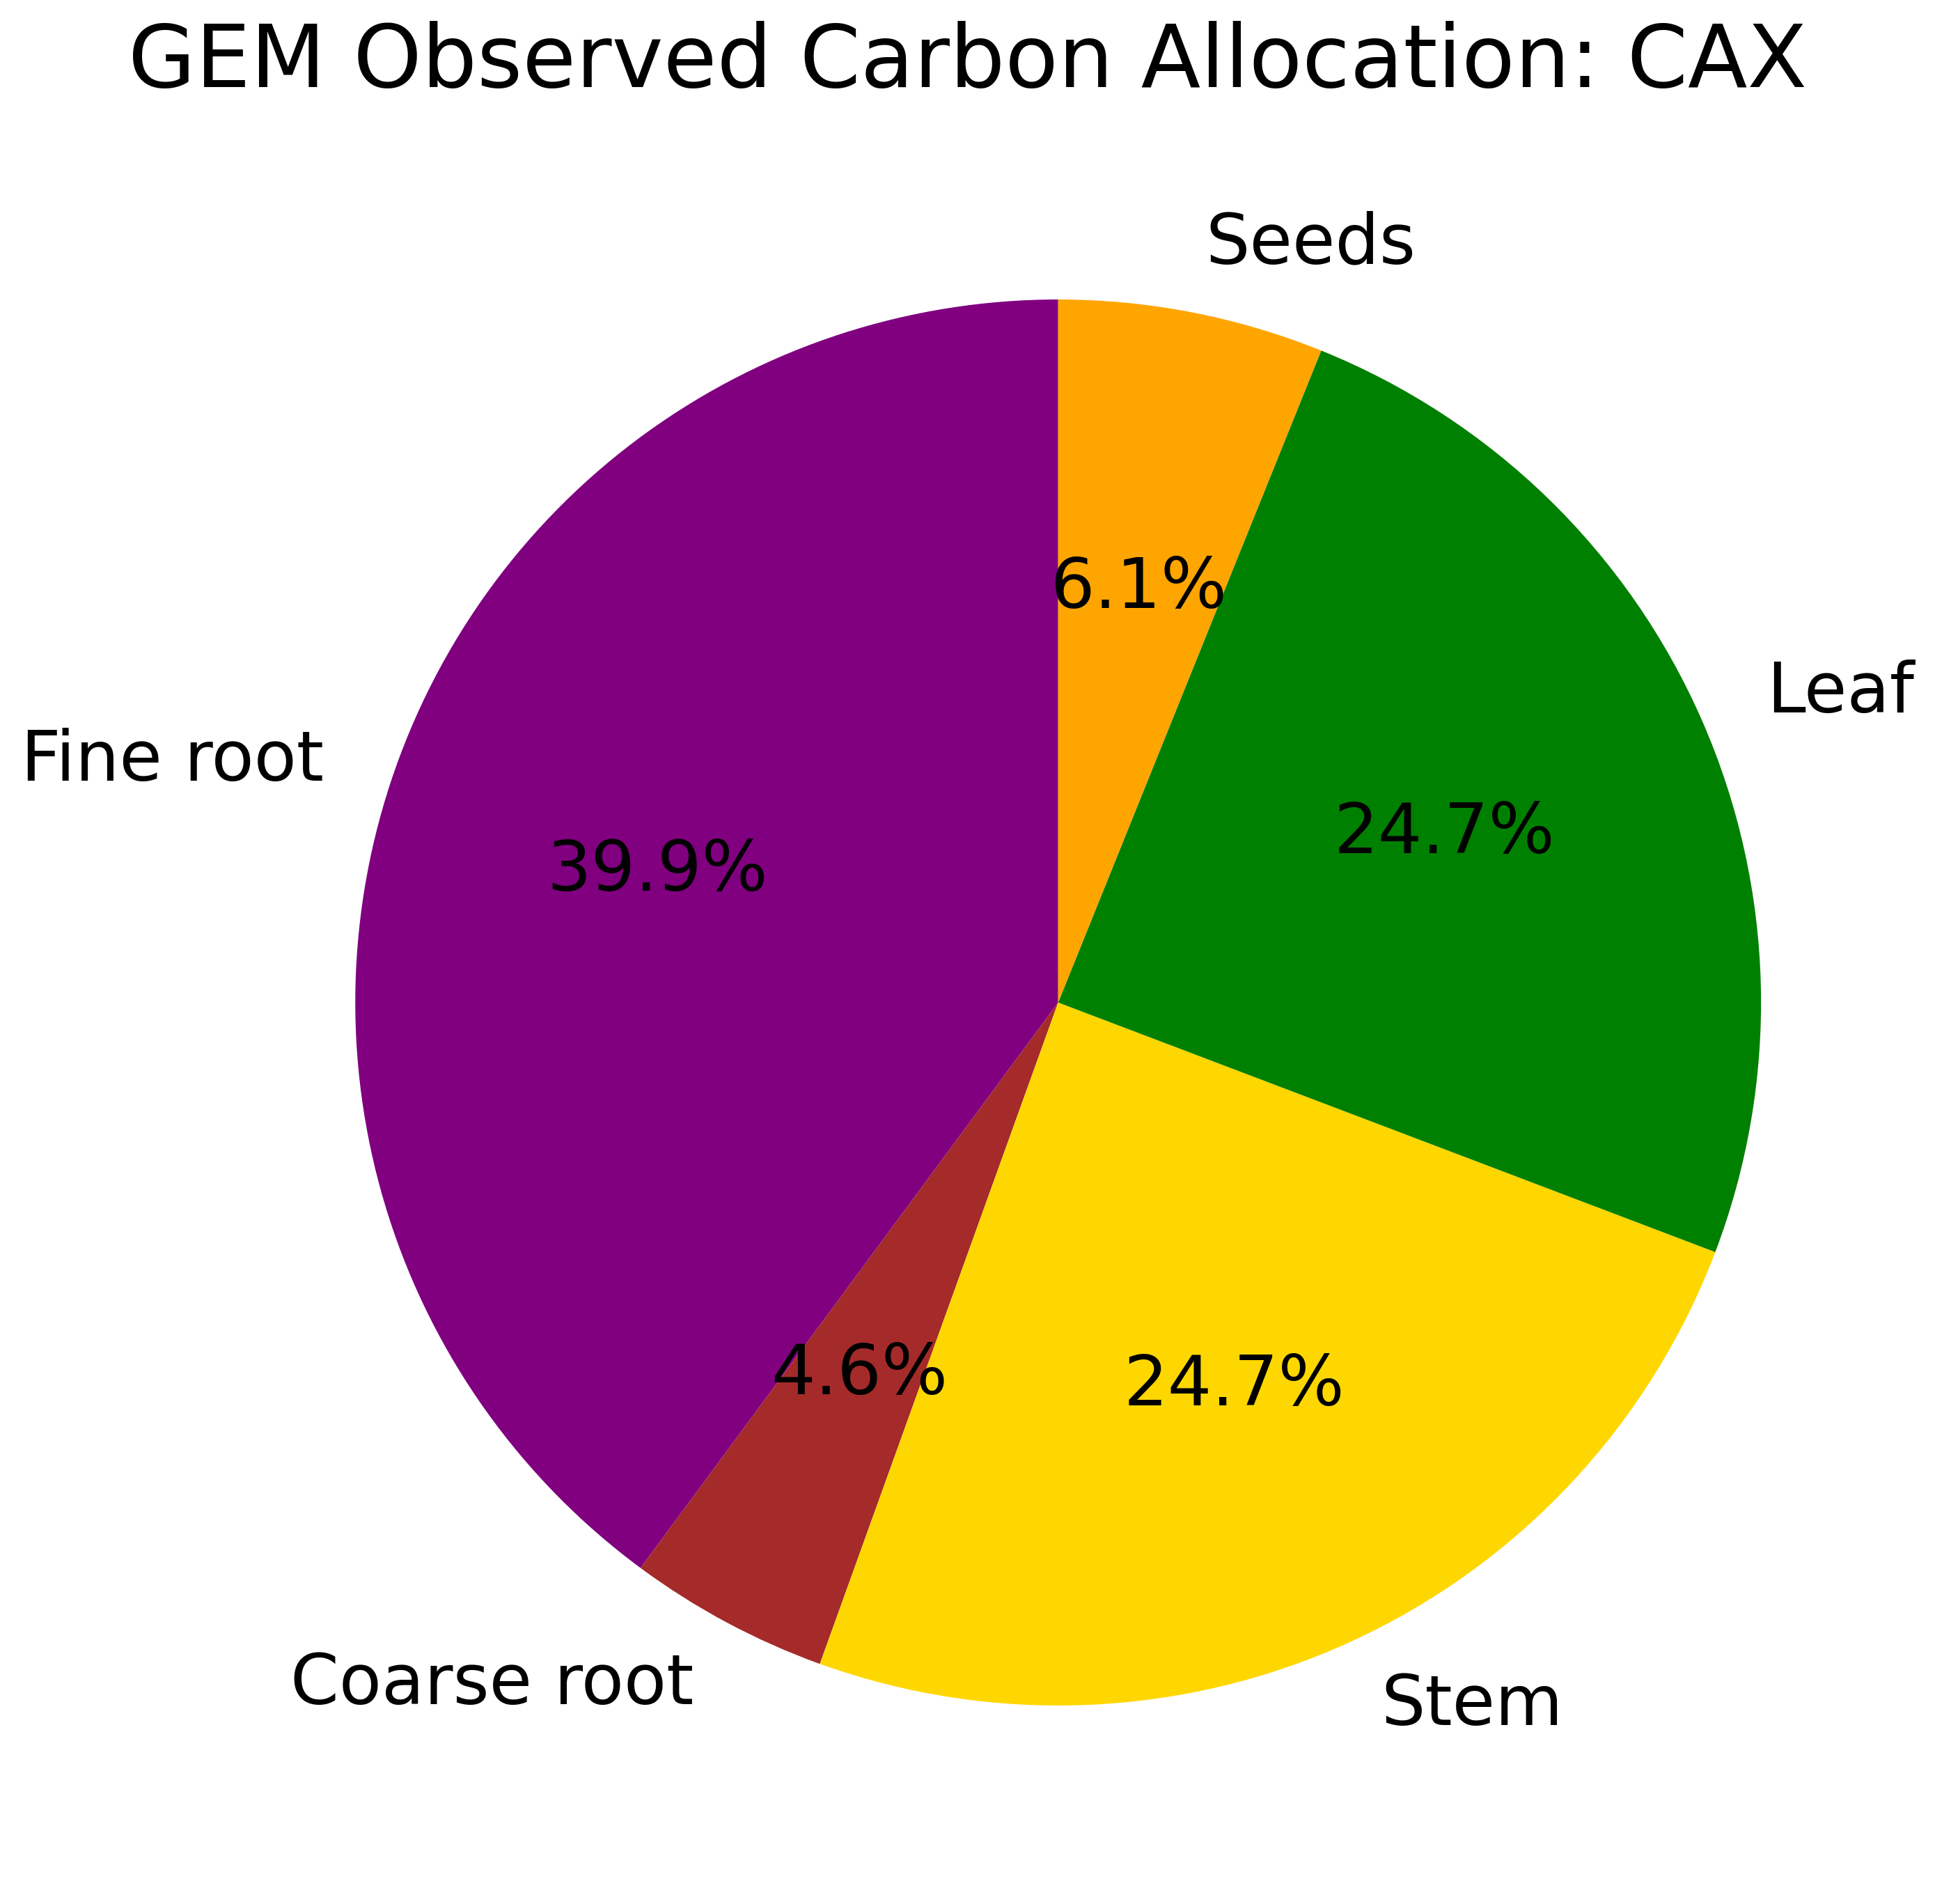

In [69]:
# Calculate means for allocation: CAX only
alloc = [
    np.nanmean(gem_npp_froot[4:7]),
    np.nanmean(gem_npp_croot[4:7]),
    np.nanmean(gem_npp_stem[4:7]),
    np.nanmean(gem_npp_leaf[4:7]),
    np.nanmean(gem_npp_seed[4:7])
]


labels = ['Fine root', 'Coarse root', 'Stem', 'Leaf', 'Seeds']
colors = ['purple', 'brown', 'gold', 'green', 'orange']

# Create figure with specific size for better readability
fig, ax = plt.subplots(figsize=(9, 9))

plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})
plt.suptitle('GEM Observed Carbon Allocation: CAX',fontsize='30')

plt.axis('equal')
plt.tight_layout()
plt.show()

In [21]:
print(df.Plot_code.values[7:9])

['TAM-05' 'TAM-06']


/tmp/ipykernel_245512/1388270413.py:21: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


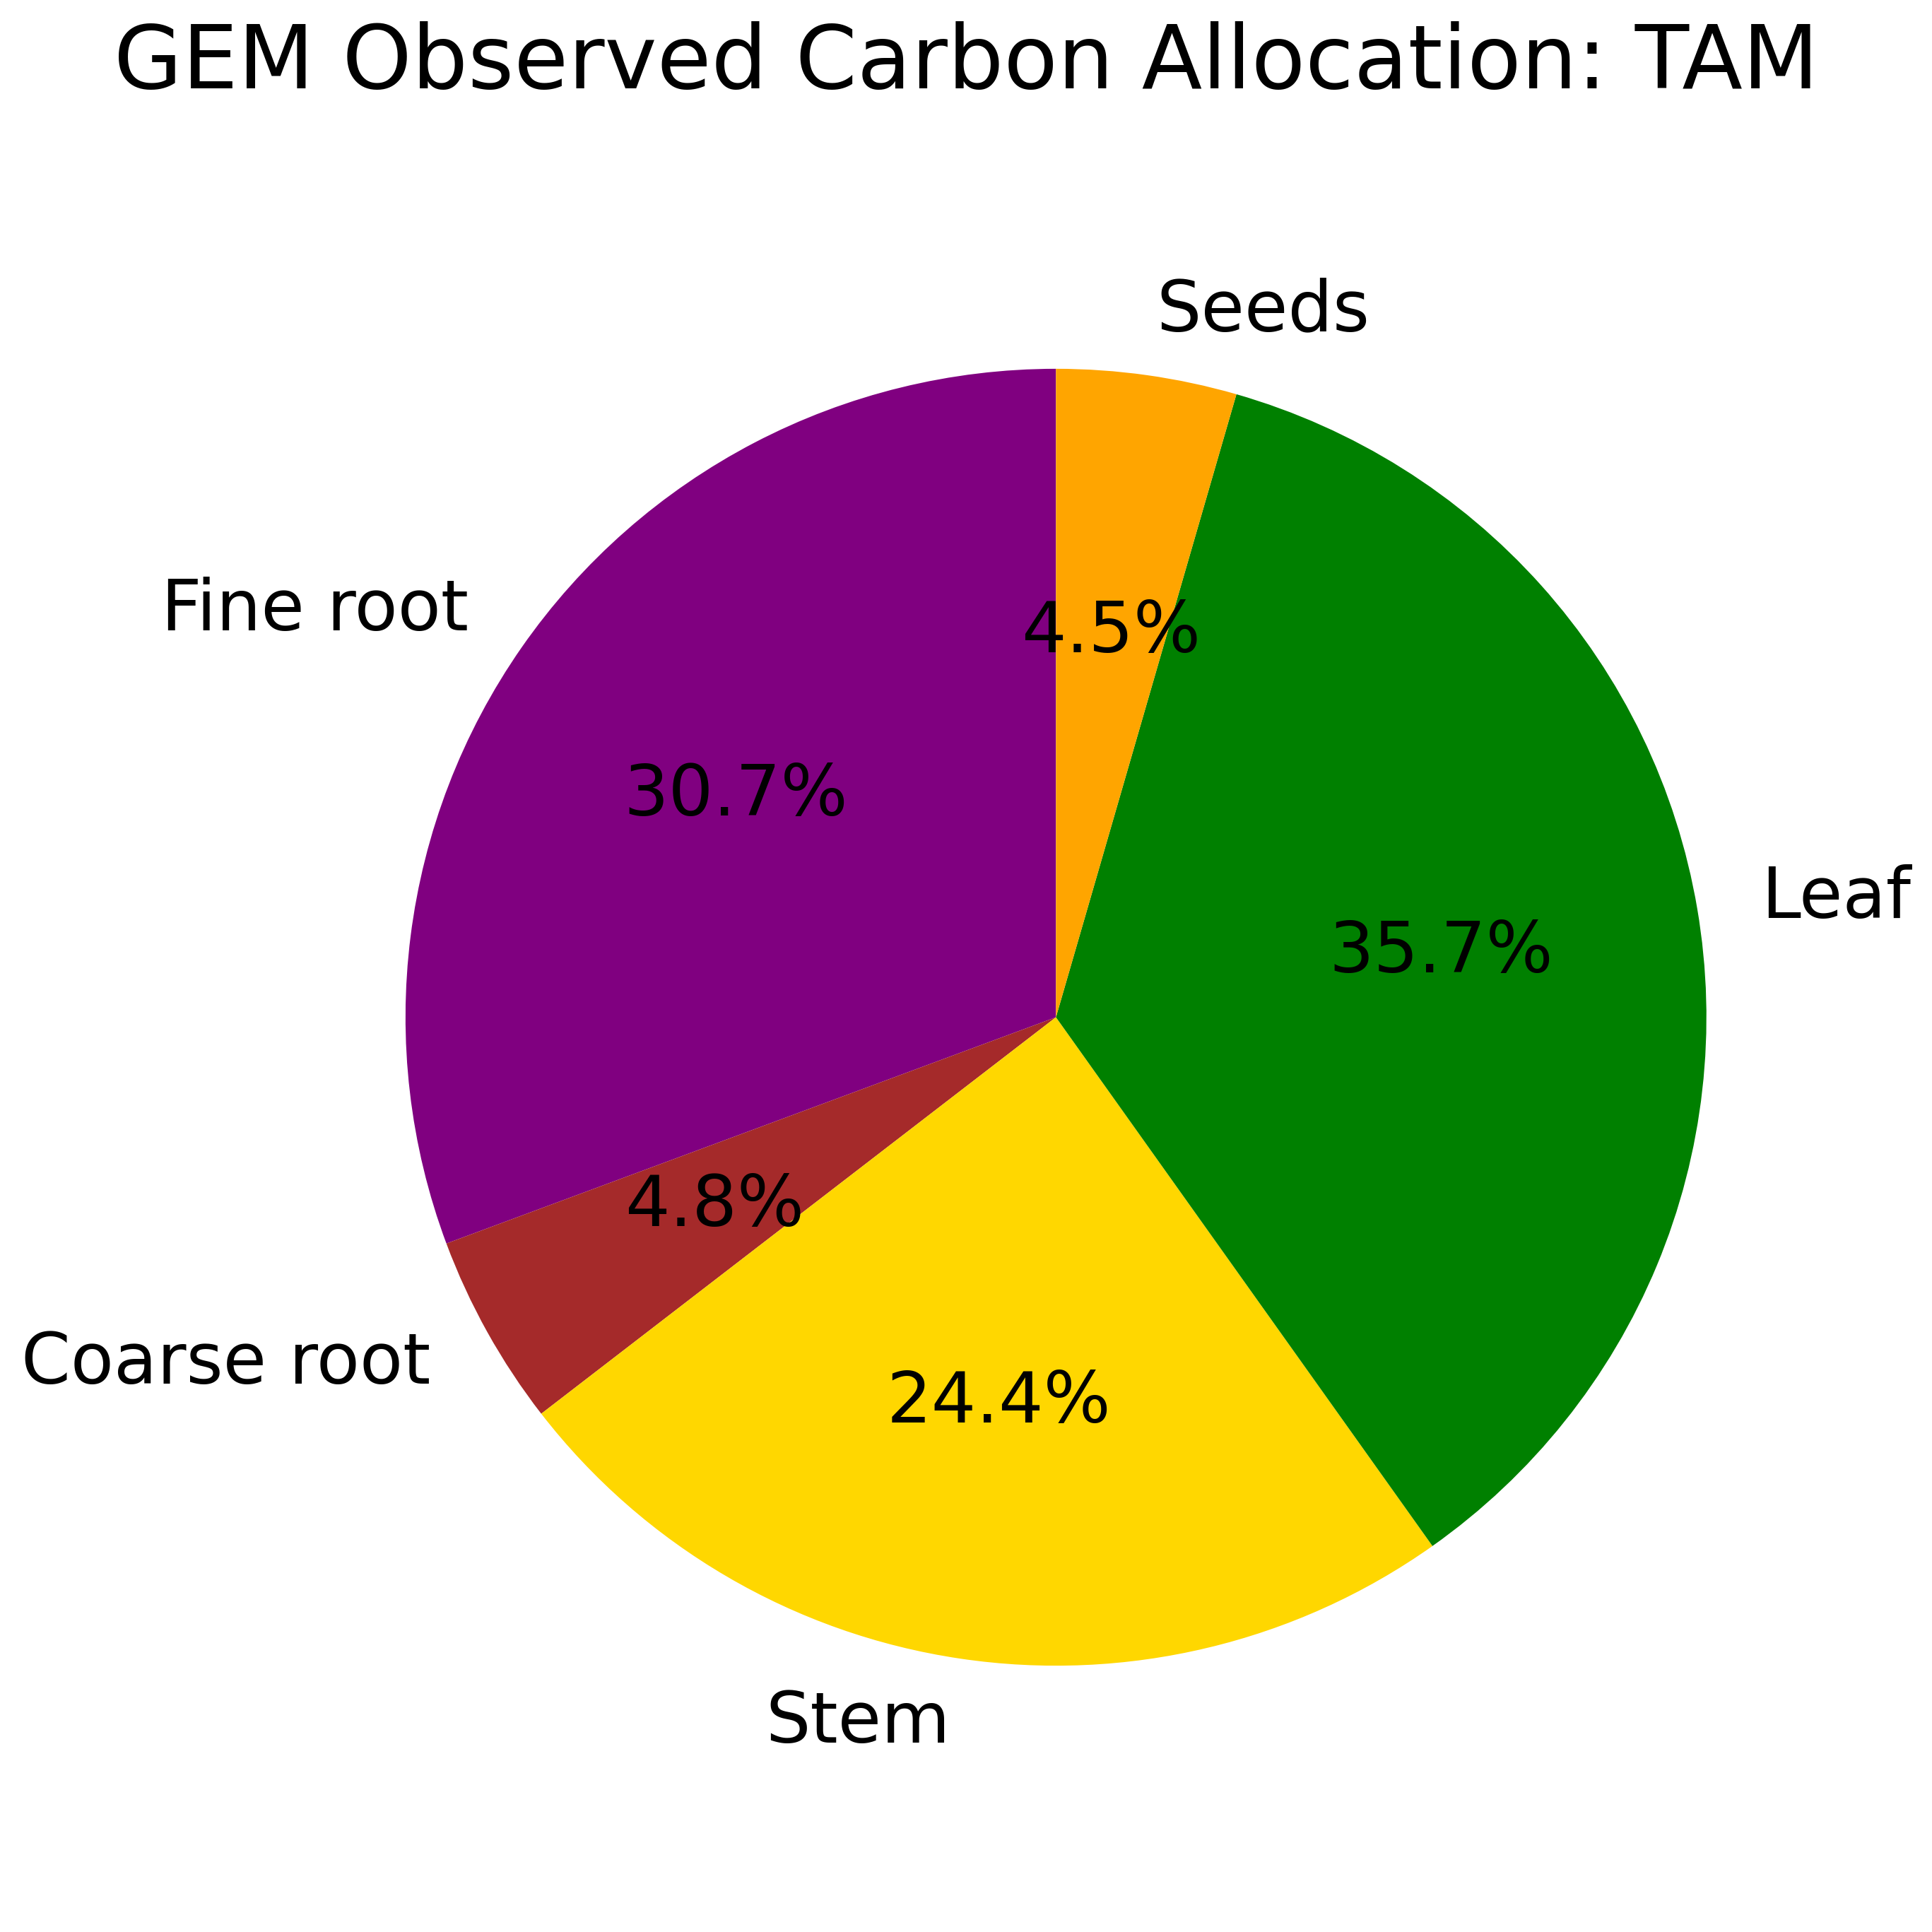

In [70]:
# Calculate means for allocation: TAM only
alloc = [
    np.nanmean(gem_npp_froot[7:9]),
    np.nanmean(gem_npp_croot[7:9]),
    np.nanmean(gem_npp_stem[7:9]),
    np.nanmean(gem_npp_leaf[7:9]),
    np.nanmean(gem_npp_seed[7:9])
]

labels = ['Fine root', 'Coarse root', 'Stem', 'Leaf', 'Seeds']
colors = ['purple', 'brown', 'gold', 'green', 'orange']


# Create figure with specific size for better readability
fig, ax = plt.subplots(figsize=(9, 9))

plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})
plt.suptitle('GEM Observed Carbon Allocation: TAM',fontsize='30')

plt.axis('equal')
plt.tight_layout()
plt.show()

In [23]:
# from Malhi et al (2012) -- this is one of the CAX sites
gem_npp_leaf=3.5
gem_npp_seed=0.6
gem_npp_stem=2.16+1.0+0.4
gem_npp_froot=2.2
gem_npp_croot=0.7
gem_npp_store=0

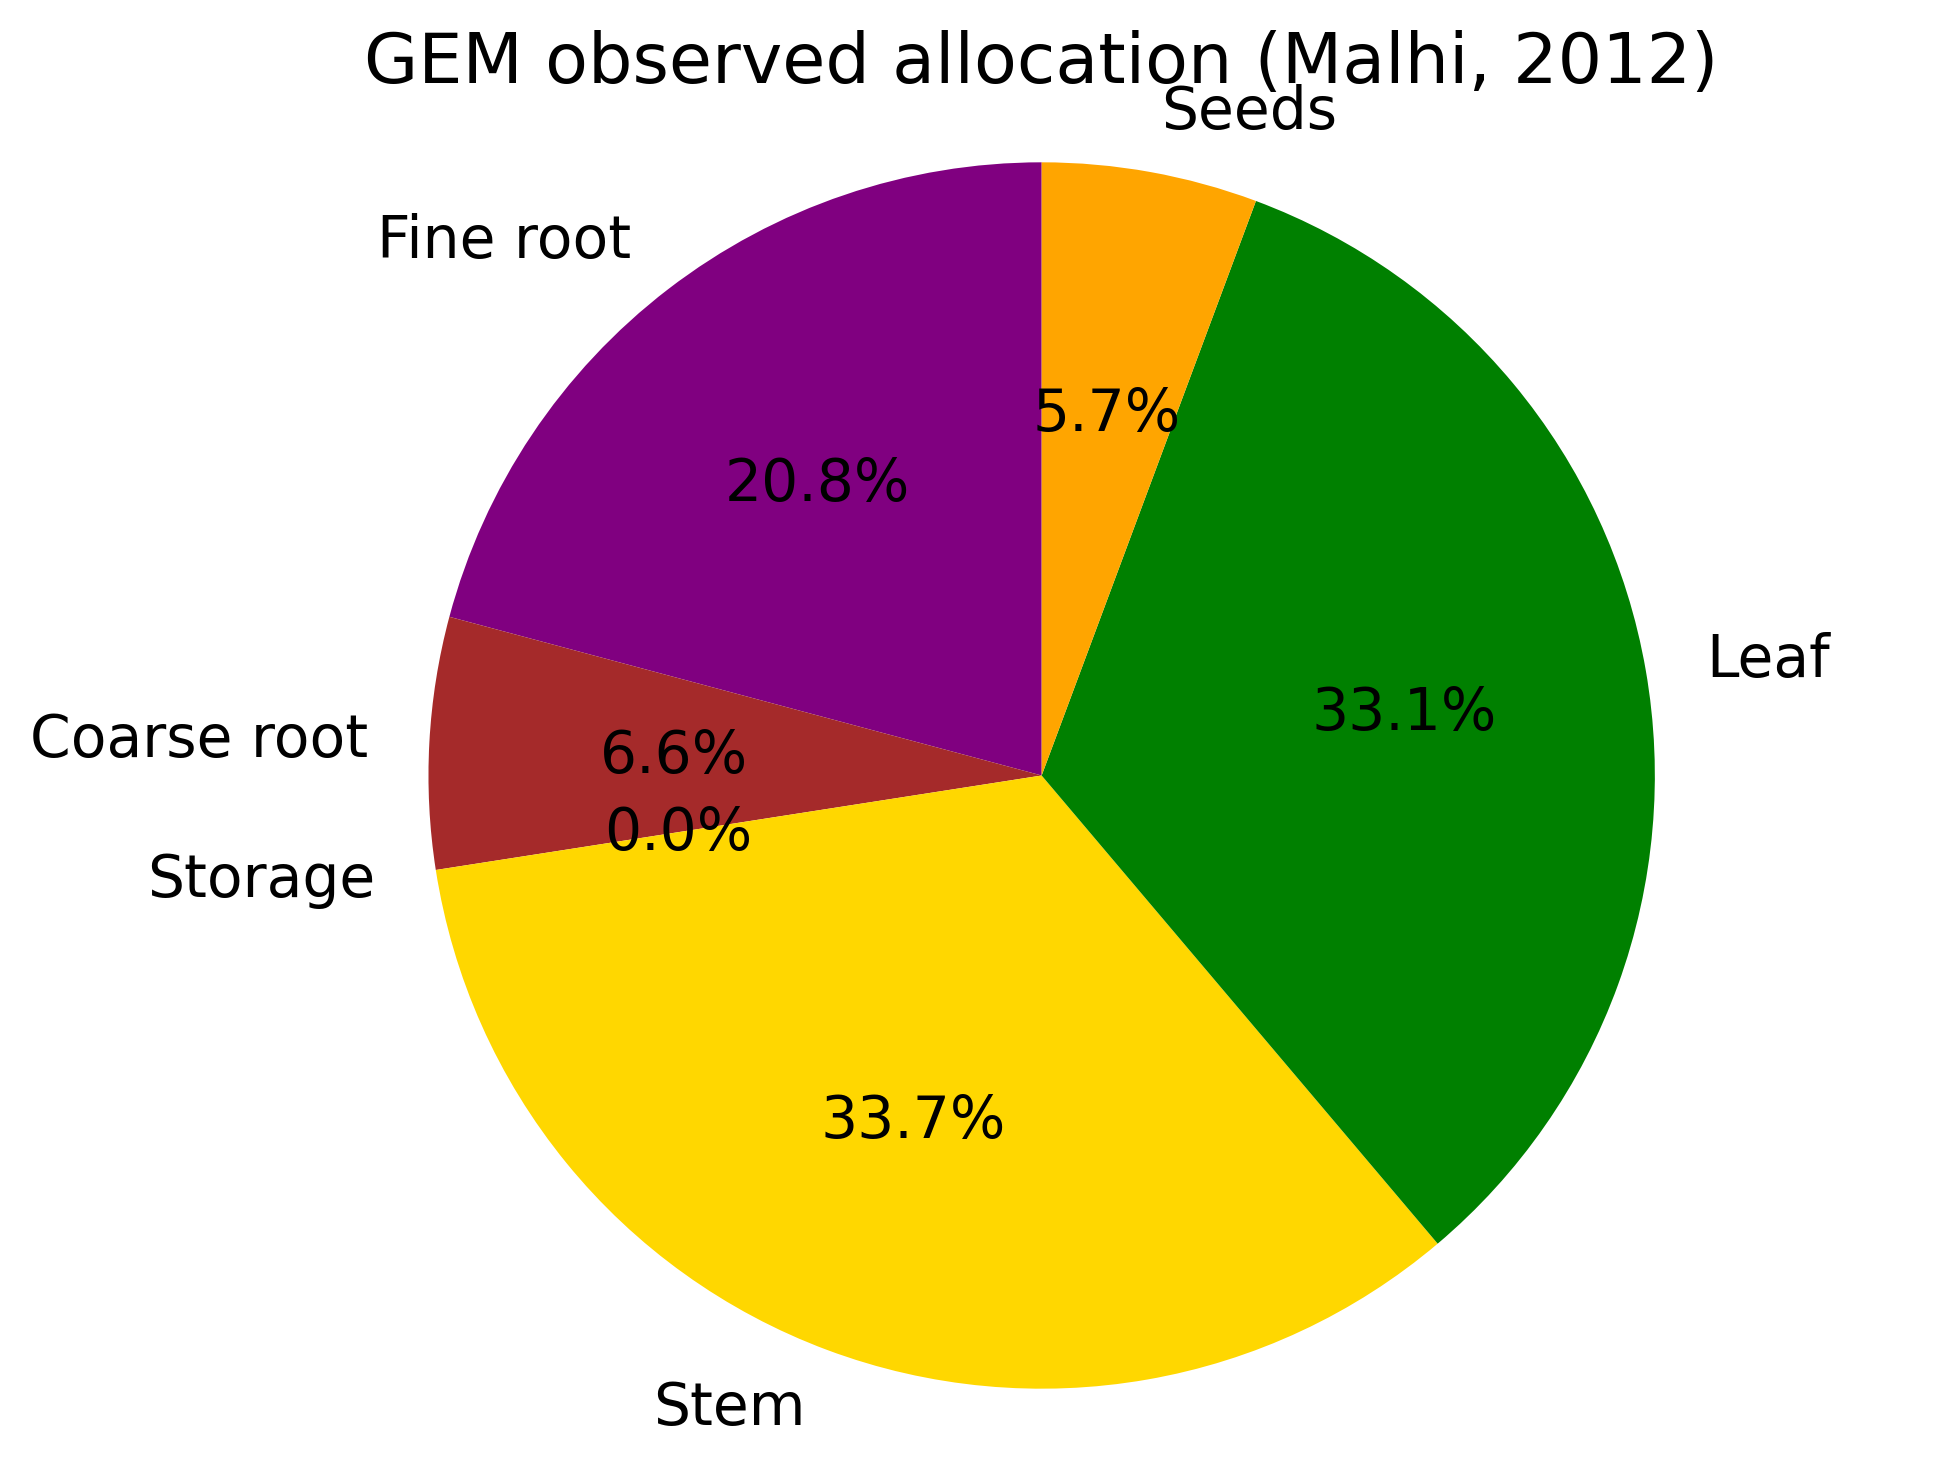

In [24]:
# Data for the pie chart
alloc = [gem_npp_froot,gem_npp_croot,gem_npp_store,gem_npp_stem,gem_npp_leaf,gem_npp_seed]
labels = ['Fine root','Coarse root','Storage','Stem','Leaf','Seeds']
colors = ['purple','brown','red','gold','green','orange']

# Create the pie chart
plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('GEM observed allocation (Malhi, 2012)')

# Ensure the circle is drawn as a circle (equal aspect ratio)
plt.axis('equal')

# Display the chart
plt.show()

In [6]:
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

In [7]:
# convert kg C /m2/s to Mg C/ha/yr for FATES output
# 1 Mg = 1000 kg
# 1 ha = 10,000 m2
# 1 yr = 31,536,000 seconds
conversion_factor = (1 / 1000.) * 10000. * 31536000

In [24]:
tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'

path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'

file=tag+'.elm.h0.cat.nc'
d0=xr.open_dataset(path+file)


In [25]:
import shapefile
from shapely.geometry import shape, Point, LinearRing

r = shapefile.Reader(Amazon_shapefile)
shapes = r.shapes()
polygon = shape(shapes[0])

## will need to change range() argument depending on resolution

## shapefile must contain center point of grid cell
Mask = [[1 if polygon.contains(Point(d0.lon[j]-360.,d0.lat[i]))==True else 0 for i in range(23)] for j in range(24)]

Mask = np.array(Mask, dtype='int16')

In [26]:
froot_npp=fa.scpf_to_scls_by_pft(d0.FATES_FROOT_ALLOC_SZPF,d0)
store_npp=fa.scpf_to_scls_by_pft(d0.FATES_STORE_ALLOC_SZPF,d0)
seed_npp=fa.scpf_to_scls_by_pft(d0.FATES_SEED_ALLOC_SZPF,d0)
leaf_npp=fa.scpf_to_scls_by_pft(d0.FATES_LEAF_ALLOC_SZPF,d0)
sapw_npp=fa.scpf_to_scls_by_pft(d0.FATES_AGSAPWOOD_ALLOC_SZPF,d0)
strct_npp=fa.scpf_to_scls_by_pft(d0.FATES_AGSTRUCT_ALLOC_SZPF,d0)

In [27]:
tot_npp=fa.scpf_to_scls_by_pft(d0.FATES_NPP_SZPF,d0)

In [28]:
croot_npp=tot_npp-(froot_npp+store_npp+seed_npp+leaf_npp+sapw_npp+strct_npp)
stem_npp=sapw_npp+strct_npp

In [29]:
d0.fates_levscls ## want to use only DBH > 10 cm to compare to GEM observations

<xarray.DataArray 'fates_levscls' (fates_levscls: 13)>
array([  0.,   5.,  10.,  15.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
       100.], dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 0.0 5.0 10.0 15.0 ... 80.0 90.0 100.0
Attributes:
    long_name:  FATES diameter size class lower bound
    units:      cm

In [30]:
froot_npp_sz=conversion_factor*froot_npp.isel(fates_levscls=slice(2,14)).mean(dim='fates_levpft').mean(dim='fates_levscls').mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
seed_npp_sz=conversion_factor*seed_npp.isel(fates_levscls=slice(2,14)).mean(dim='fates_levpft').mean(dim='fates_levscls').mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
leaf_npp_sz=conversion_factor*leaf_npp.isel(fates_levscls=slice(2,14)).mean(dim='fates_levpft').mean(dim='fates_levscls').mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
stem_npp_sz=conversion_factor*stem_npp.isel(fates_levscls=slice(2,14)).mean(dim='fates_levpft').mean(dim='fates_levscls').mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
croot_npp_sz=conversion_factor*croot_npp.isel(fates_levscls=slice(2,14)).mean(dim='fates_levpft').mean(dim='fates_levscls').mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data

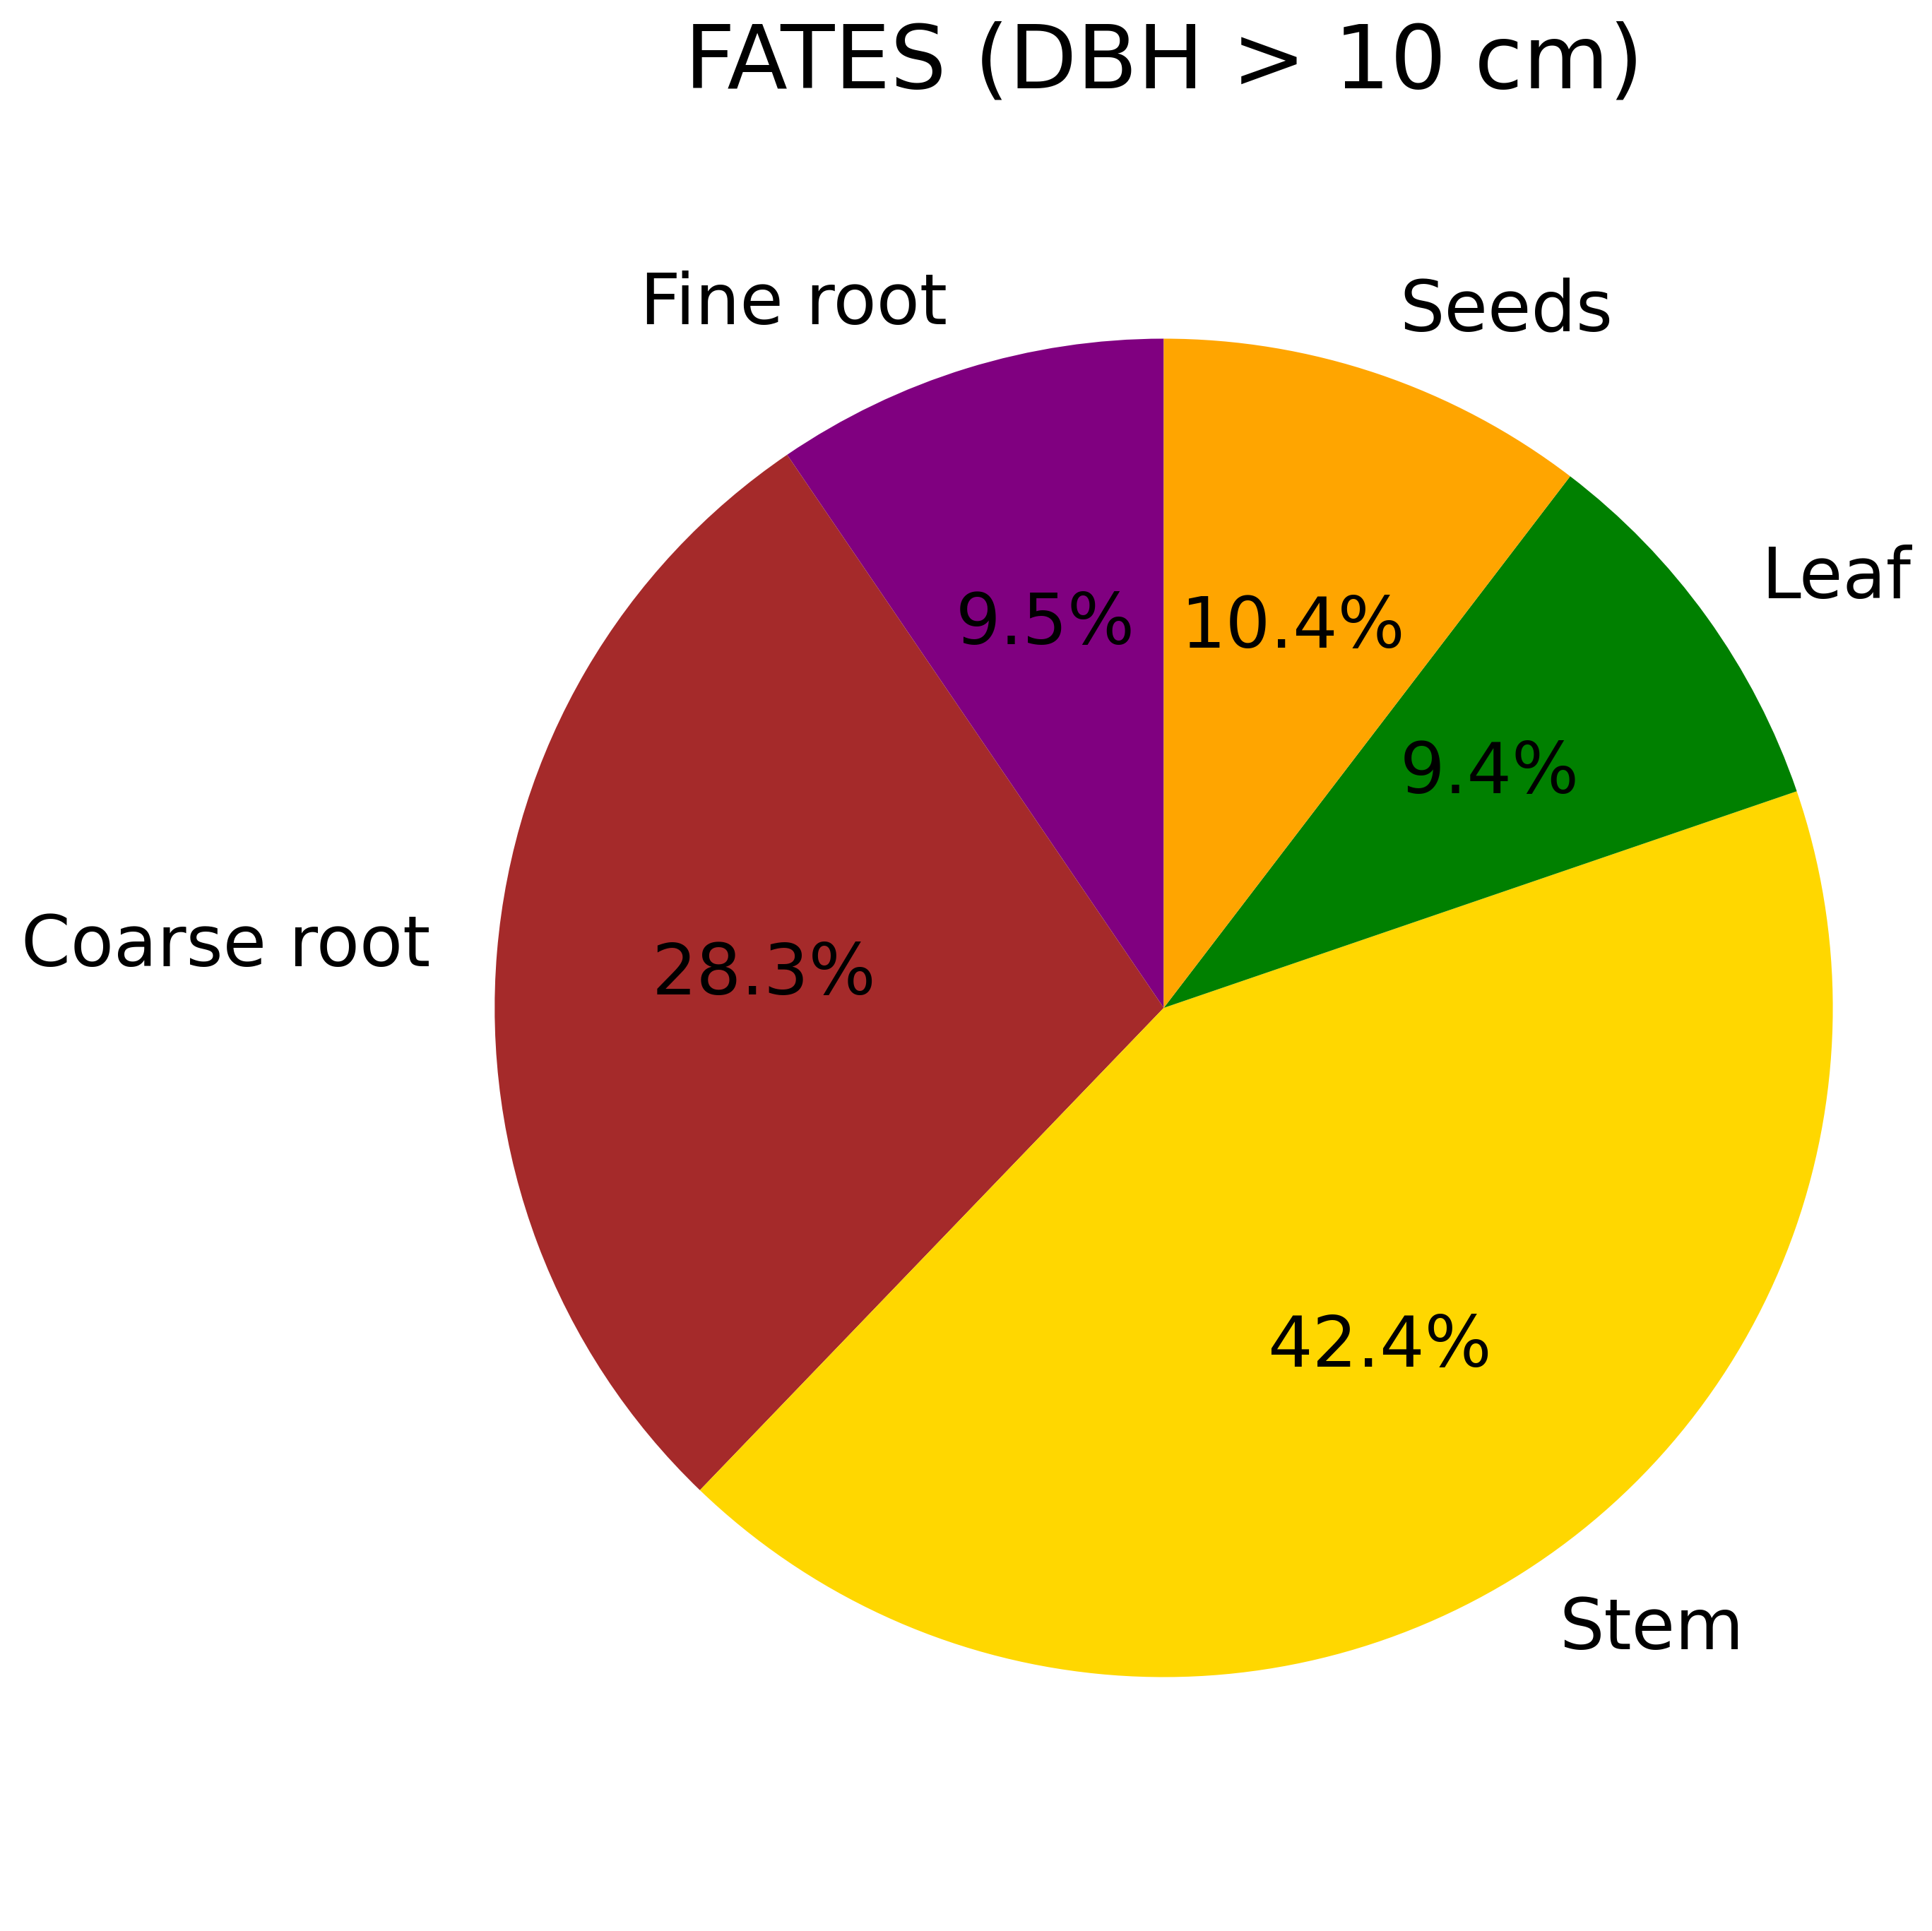

In [31]:
#store_npp=np.amax([store_npp,0])

## Data for the pie chart

alloc = [froot_npp_sz,croot_npp_sz,stem_npp_sz,leaf_npp_sz,seed_npp_sz]
labels = ['Fine root','Coarse root','Stem','Leaf','Seeds']
colors = ['purple','brown','gold','green','orange']

fig, ax = plt.subplots(figsize=(9, 9))

# Create the pie chart
plt.pie(alloc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,textprops={'fontsize': 24})

# Add a title
plt.title('FATES (DBH > 10 cm)',fontsize=30)

# Ensure the circle is drawn as a circle (equal aspect ratio)
plt.axis('equal')

# Display the chart
plt.show()

In [16]:
## Make pie chart for each PFT x size class

In [52]:
def pie_chart_szpf(pft_ind,size_class_ind, ax=None):

    if ax is None:
        ax = plt.gca()  # Fallback to current axis if none is provided
        
    froot_npp1=froot_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    store_npp1=store_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    seed_npp1=seed_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    leaf_npp1=leaf_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    sapw_npp1=sapw_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    strct_npp1=strct_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data
    croot_npp1=croot_npp.isel(fates_levpft=pft_ind).isel(fates_levscls=size_class_ind).mean(dim='time').where(np.transpose(Mask) > 0).mean(dim='lat').mean(dim='lon').data

    store_npp1=np.amax([store_npp1,0])
    stem=sapw_npp1+strct_npp1

    alloc = [froot_npp1,croot_npp1,stem,leaf_npp1,seed_npp1,store_npp1]
    labels = ['Fine root','Coarse root','Stem','Leaf','Seeds','Storage']
    colors = ['purple','brown','gold','green','orange','cyan']

# Create the pie chart
    ax.pie(alloc,colors=colors,autopct='%1.1f%%', startangle=90)#, labels=labels)

# Add a title
    ax.set_title('min DBH '+str(d0.fates_levscls.isel(fates_levscls=size_class_ind).data)+' cm')

# Ensure the circle is drawn as a circle (equal aspect ratio)
    ax.axis('equal')

/tmp/ipykernel_245512/1687116140.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


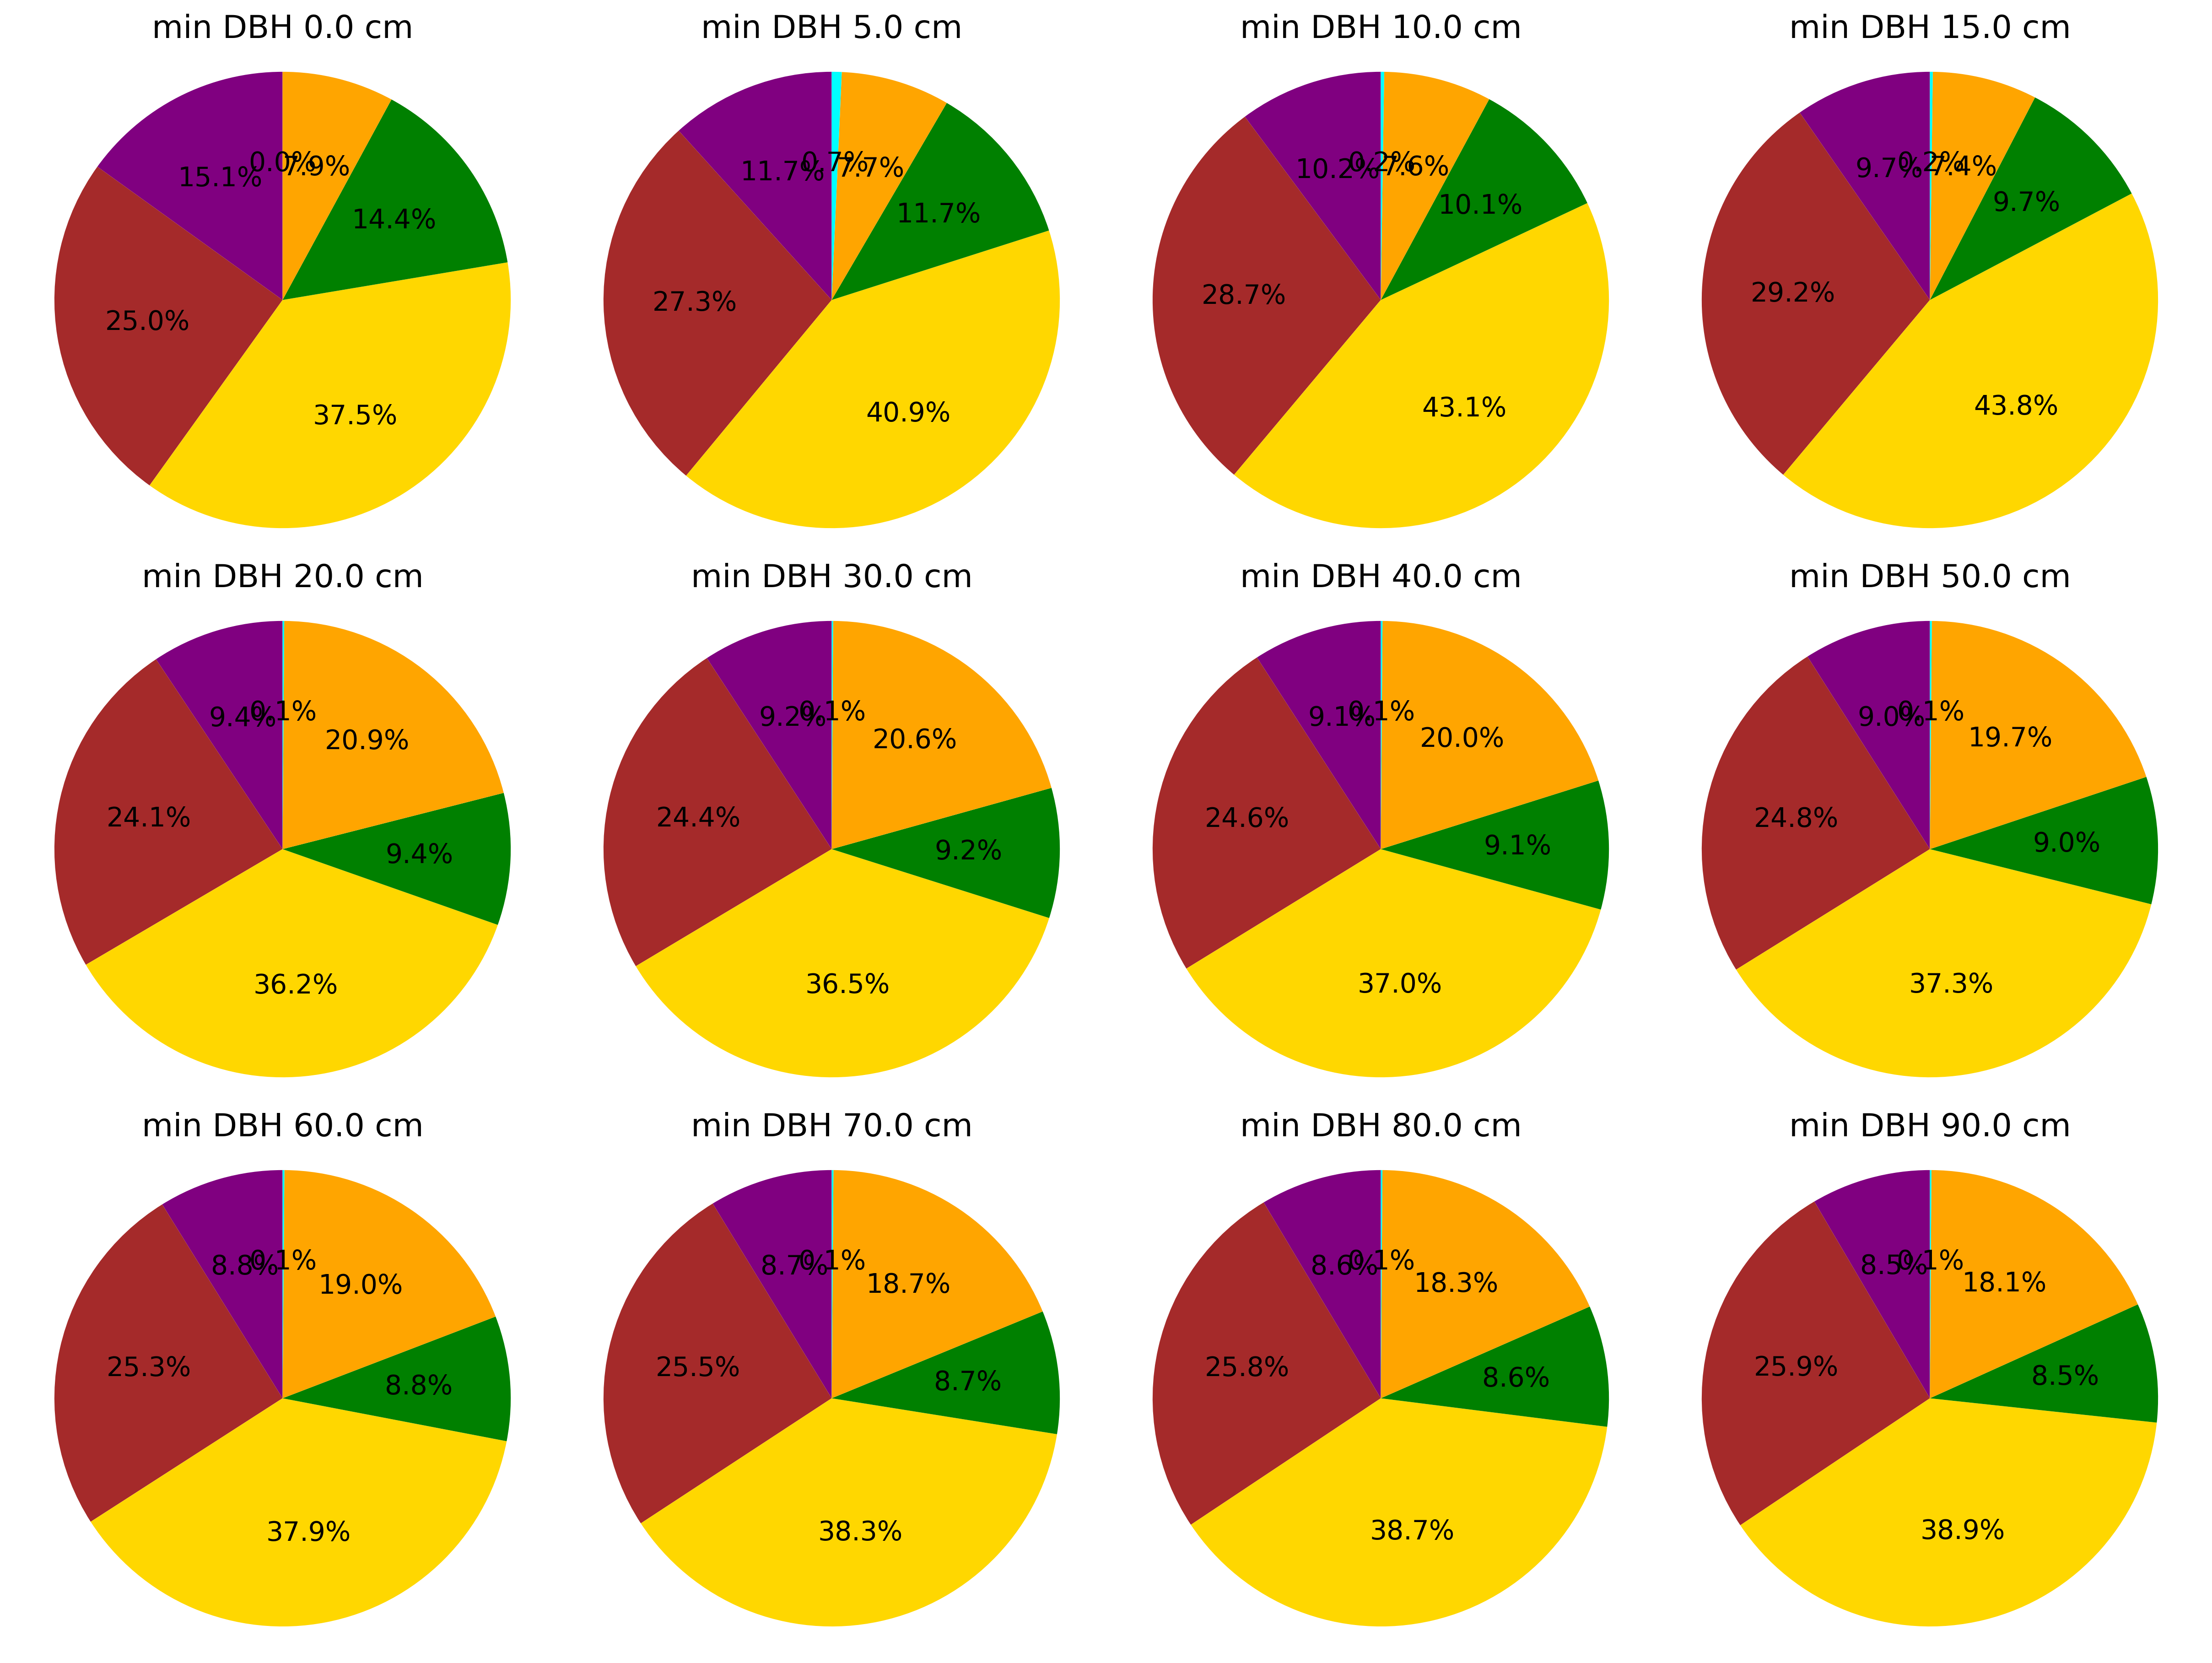

In [53]:
# 1. Define PFT index
pft_index = 0  

# 2. Initialize a figure with 3 rows and 4 columns
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))

# 3. Flatten the 2D array of axes to easily loop from 0 to 11
axes_flat = axes.flatten()

# 4. Loop through each size class and its corresponding subplot axis
for size_class in range(12):
    current_ax = axes_flat[size_class]
    
    # Call your function, passing the specific axis
    pie_chart_szpf(pft_ind=pft_index, size_class_ind=size_class, ax=current_ax)

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

/tmp/ipykernel_245512/2978460276.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


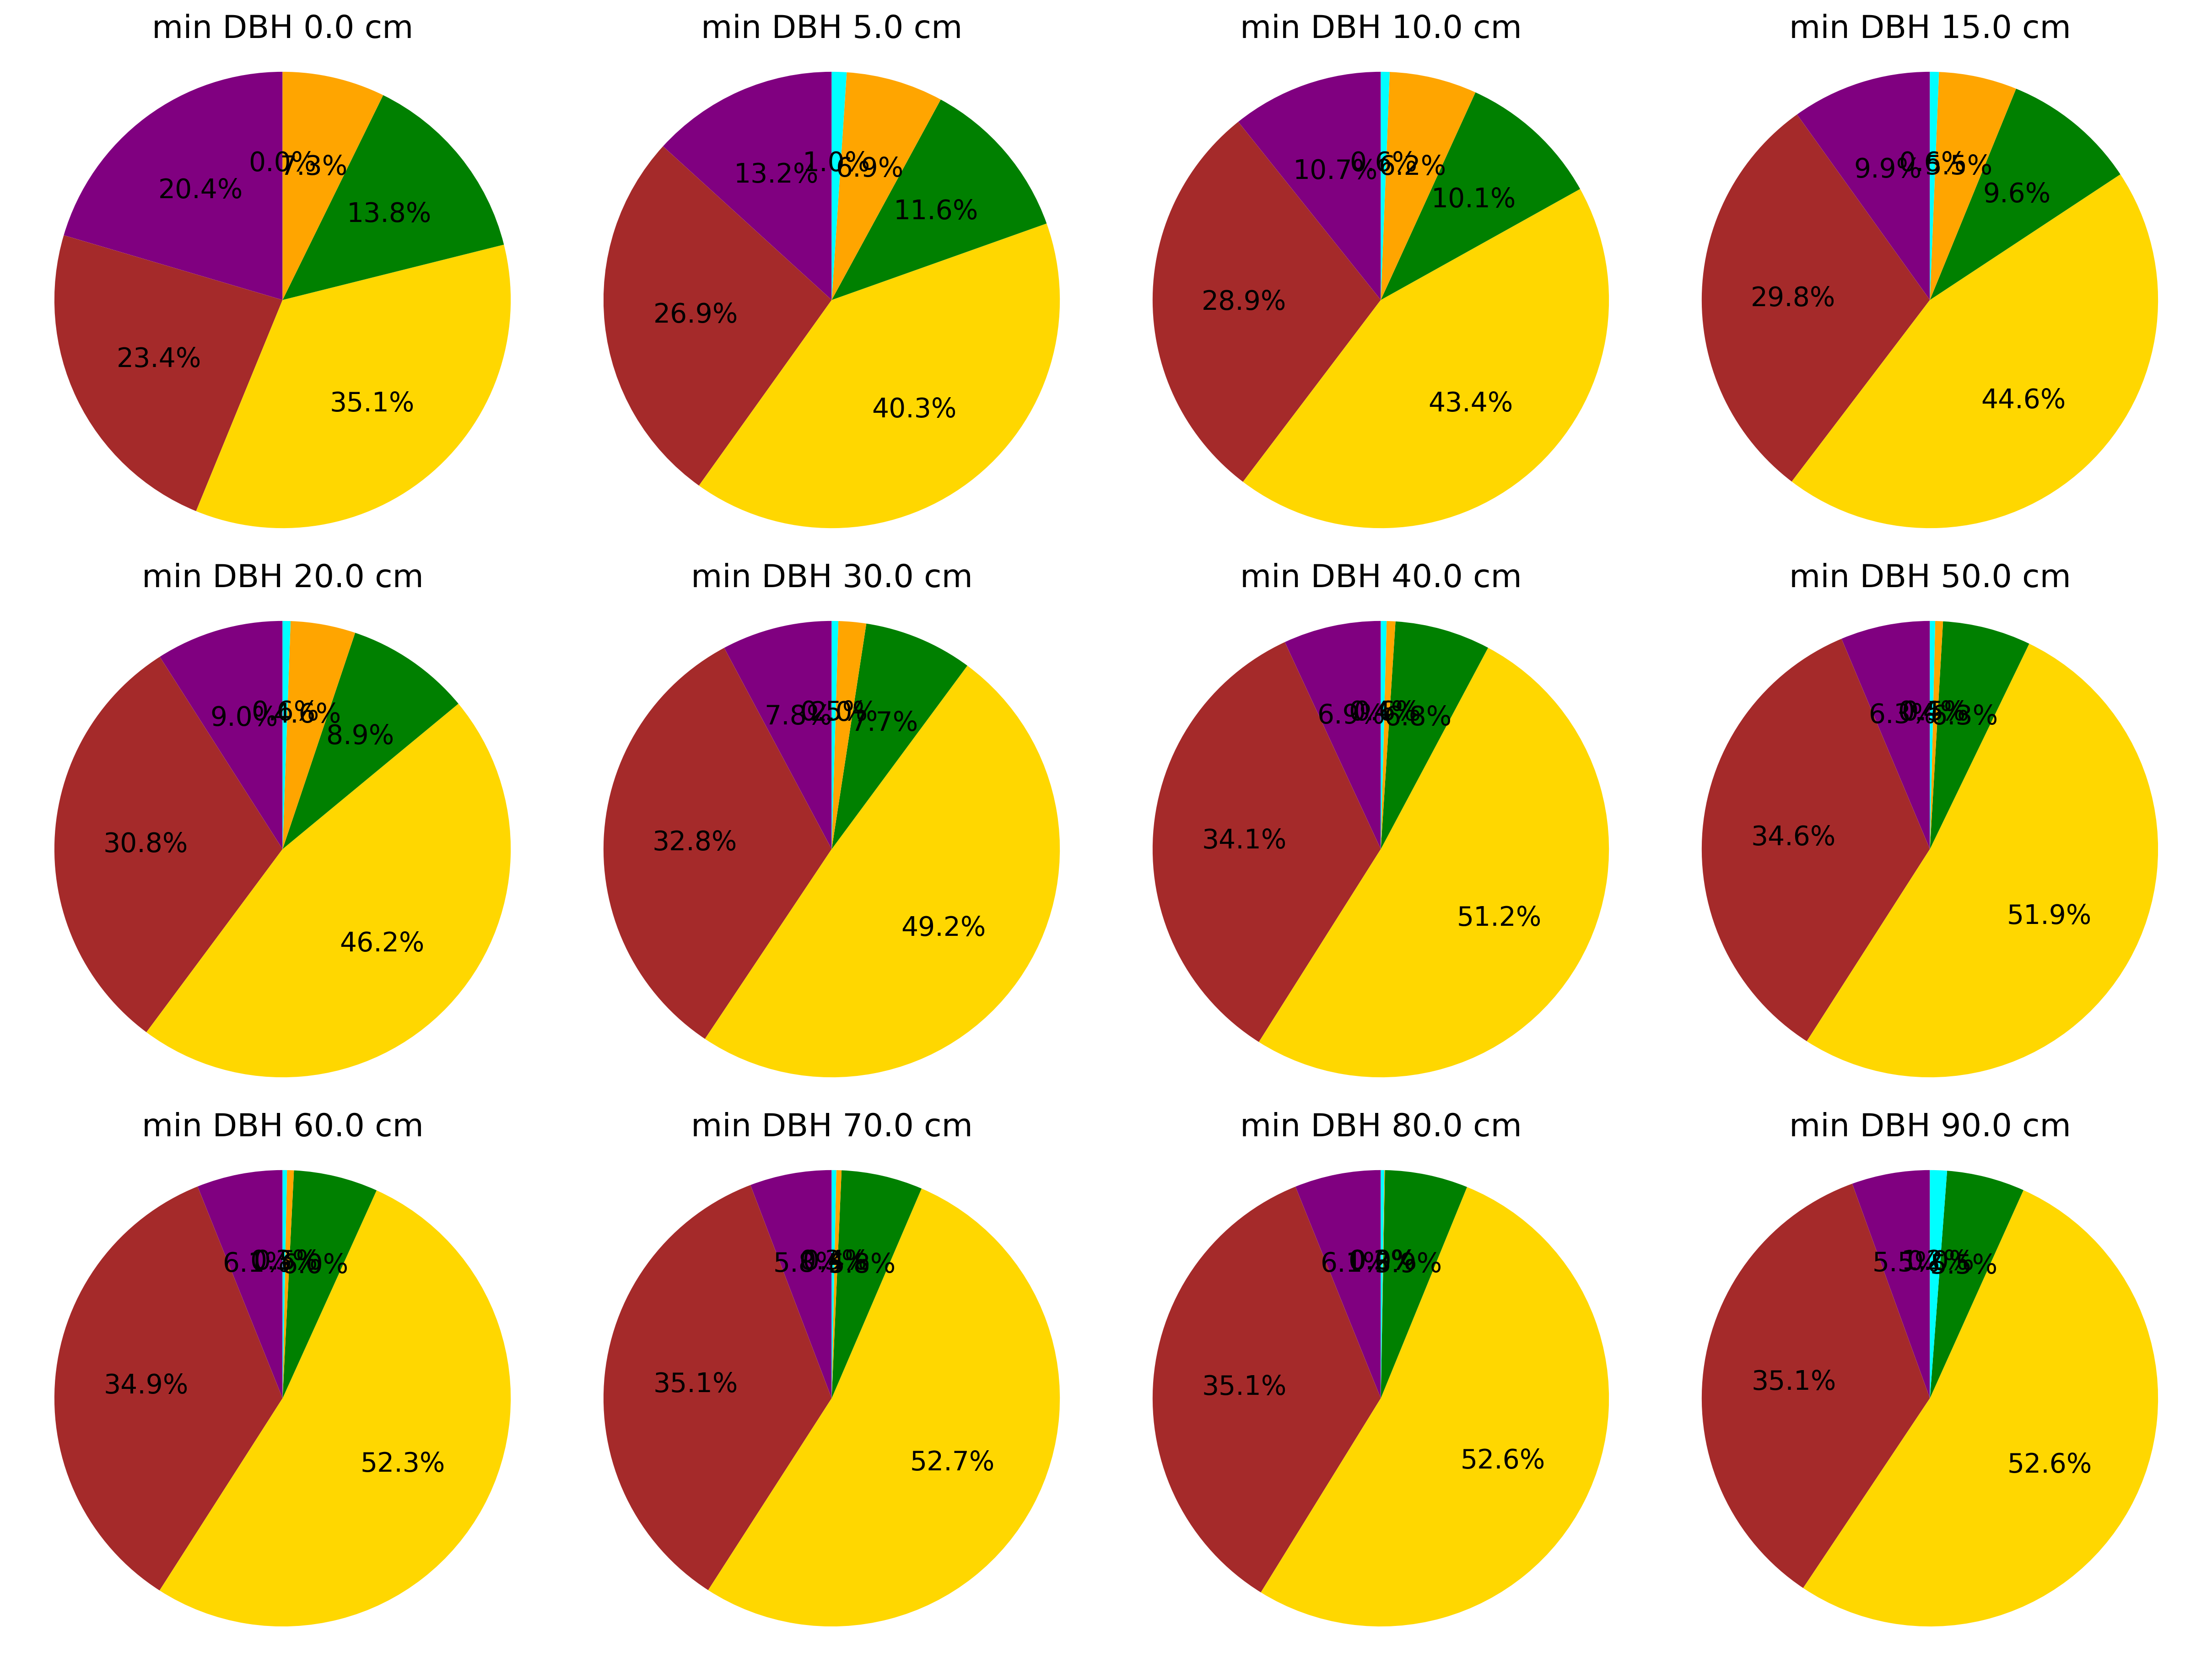

In [54]:
# 1. Define PFT index
pft_index = 1  

# 2. Initialize a figure with 3 rows and 4 columns
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))

# 3. Flatten the 2D array of axes to easily loop from 0 to 11
axes_flat = axes.flatten()

# 4. Loop through each size class and its corresponding subplot axis
for size_class in range(12):
    current_ax = axes_flat[size_class]
    
    # Call your function, passing the specific axis
    pie_chart_szpf(pft_ind=pft_index, size_class_ind=size_class, ax=current_ax)

# 5. Clean up layout and display
plt.tight_layout()
plt.show()

In [14]:
# average over PFT, size class, and time first, leaving 'lat' and 'lon' intact.
froot_spatial = (conversion_factor * froot_npp
                 .isel(fates_levscls=slice(2, 14))
                 .mean(dim='fates_levpft')
                 .mean(dim='fates_levscls')
                 .mean(dim='time')
                 .where(np.transpose(Mask) > 0))

seed_spatial = (conversion_factor * seed_npp
                .isel(fates_levscls=slice(2, 14))
                .mean(dim='fates_levpft')
                .mean(dim='fates_levscls')
                .mean(dim='time')
                .where(np.transpose(Mask) > 0))

leaf_spatial = (conversion_factor * leaf_npp
                .isel(fates_levscls=slice(2, 14))
                .mean(dim='fates_levpft')
                .mean(dim='fates_levscls')
                .mean(dim='time')
                .where(np.transpose(Mask) > 0))

stem_spatial = (conversion_factor * stem_npp
                .isel(fates_levscls=slice(2, 14))
                .mean(dim='fates_levpft')
                .mean(dim='fates_levscls')
                .mean(dim='time')
                .where(np.transpose(Mask) > 0))

croot_spatial = (conversion_factor * croot_npp
                 .isel(fates_levscls=slice(2, 14))
                 .mean(dim='fates_levpft')
                 .mean(dim='fates_levscls')
                 .mean(dim='time')
                 .where(np.transpose(Mask) > 0))

# Extract spatial means 
froot_npp_sz = froot_spatial.mean(dim=['lat', 'lon']).data
seed_npp_sz  = seed_spatial.mean(dim=['lat', 'lon']).data
leaf_npp_sz  = leaf_spatial.mean(dim=['lat', 'lon']).data
stem_npp_sz  = stem_spatial.mean(dim=['lat', 'lon']).data
croot_npp_sz = croot_spatial.mean(dim=['lat', 'lon']).data

# Extract standard deviation
froot_npp_std = froot_spatial.std(dim=['lat', 'lon']).data
seed_npp_std  = seed_spatial.std(dim=['lat', 'lon']).data
leaf_npp_std  = leaf_spatial.std(dim=['lat', 'lon']).data
stem_npp_std  = stem_spatial.std(dim=['lat', 'lon']).data
croot_npp_std = croot_spatial.std(dim=['lat', 'lon']).data

/tmp/ipykernel_255271/3315952031.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


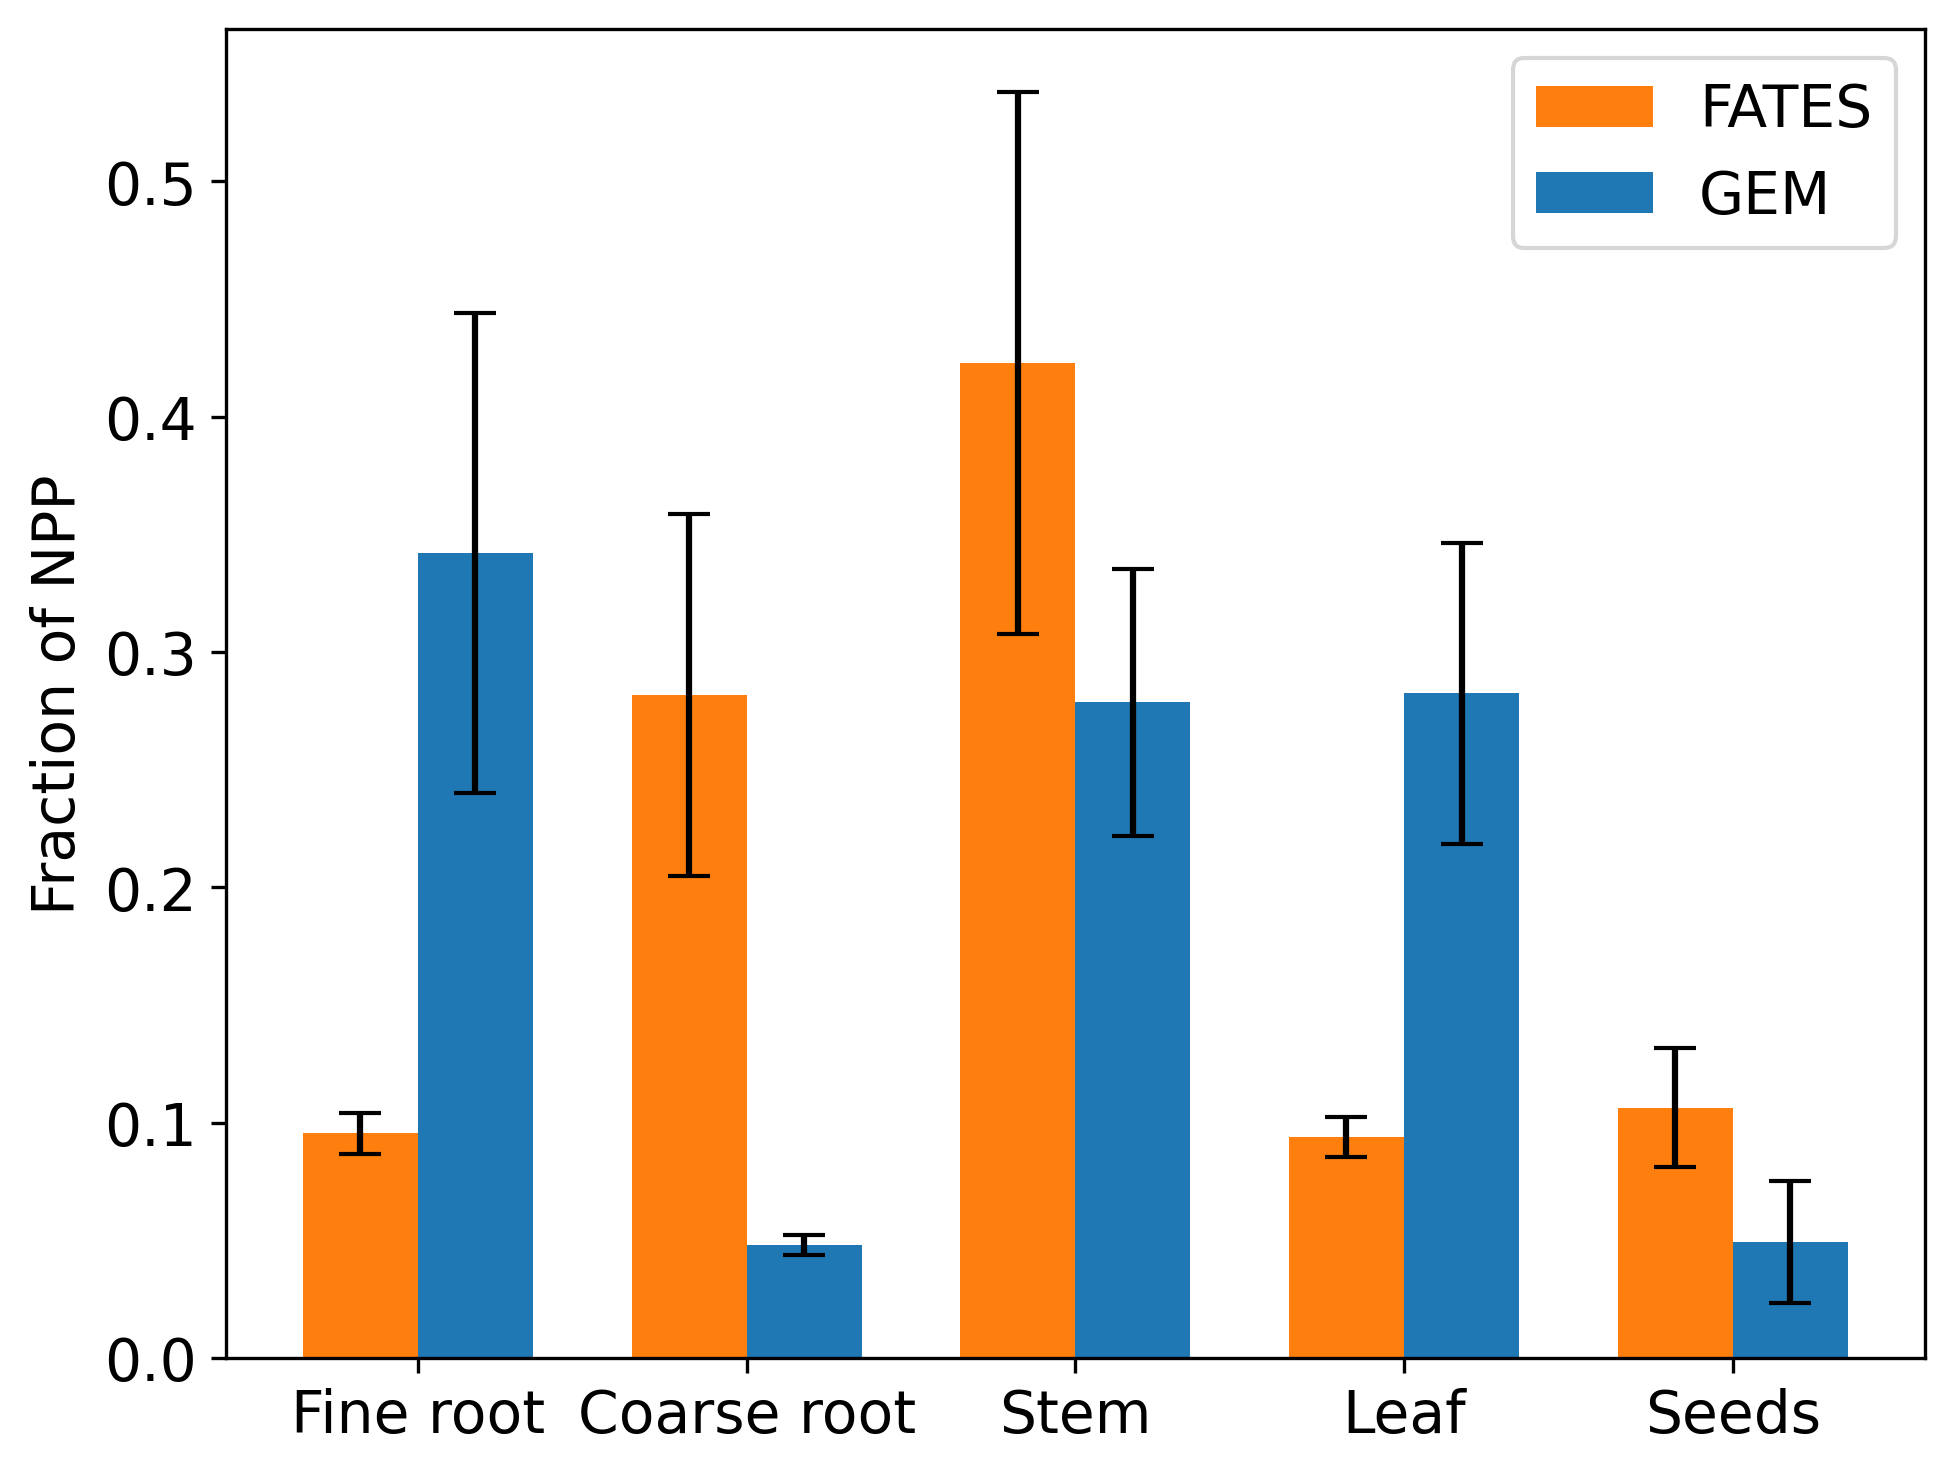

In [15]:
# Make a bar chart showing fraction of NPP in each category with bars for FATES & GEM

fates_alloc = [froot_npp_sz, croot_npp_sz, stem_npp_sz, leaf_npp_sz, seed_npp_sz]
fates_std = [froot_npp_std, croot_npp_std, stem_npp_std, leaf_npp_std, seed_npp_std]

gem_alloc= [
    np.nanmean(gem_npp_froot[0:9]),
    np.nanmean(gem_npp_croot[0:9]),
    np.nanmean(gem_npp_stem[0:9]),
    np.nanmean(gem_npp_leaf[0:9]),
    np.nanmean(gem_npp_seed[0:9])
]

gem_std = [
    np.nanstd(gem_npp_froot[0:9]),
    np.nanstd(gem_npp_croot[0:9]),
    np.nanstd(gem_npp_stem[0:9]),
    np.nanstd(gem_npp_leaf[0:9]),
    np.nanstd(gem_npp_seed[0:9]),
]

labels = ['Fine root','Coarse root','Stem','Leaf','Seeds']

# --- Convert absolute allocations to fractions and scale SDs---
fates_frac       = np.array(fates_alloc) / np.sum(fates_alloc)
fates_std_frac   = np.array(fates_std) / np.sum(fates_alloc)

gem_frac = np.array(gem_alloc) / np.sum(gem_alloc)
gem_std_frac = np.array(gem_std) / np.sum(gem_alloc)

x = np.arange(len(labels))  # Label locations
width = 0.35  # Width of each individual bar

# Plot FATES 
plt.bar(x - width/2, fates_frac, width, yerr=fates_std_frac, 
        label='FATES', color='#ff7f0e', capsize=5, ecolor='black')

# Plot GEM 
plt.bar(x + width/2, gem_frac, width, yerr=gem_std_frac, 
        label='GEM', color='#1f77b4', capsize=5, ecolor='black')

plt.ylabel("Fraction of NPP")
#plt.title("NPP Allocation: FATES vs GEM")
plt.xticks(x, labels)
plt.legend()

# Ensure labels are non-overlapping and everything fits nicely
plt.tight_layout()

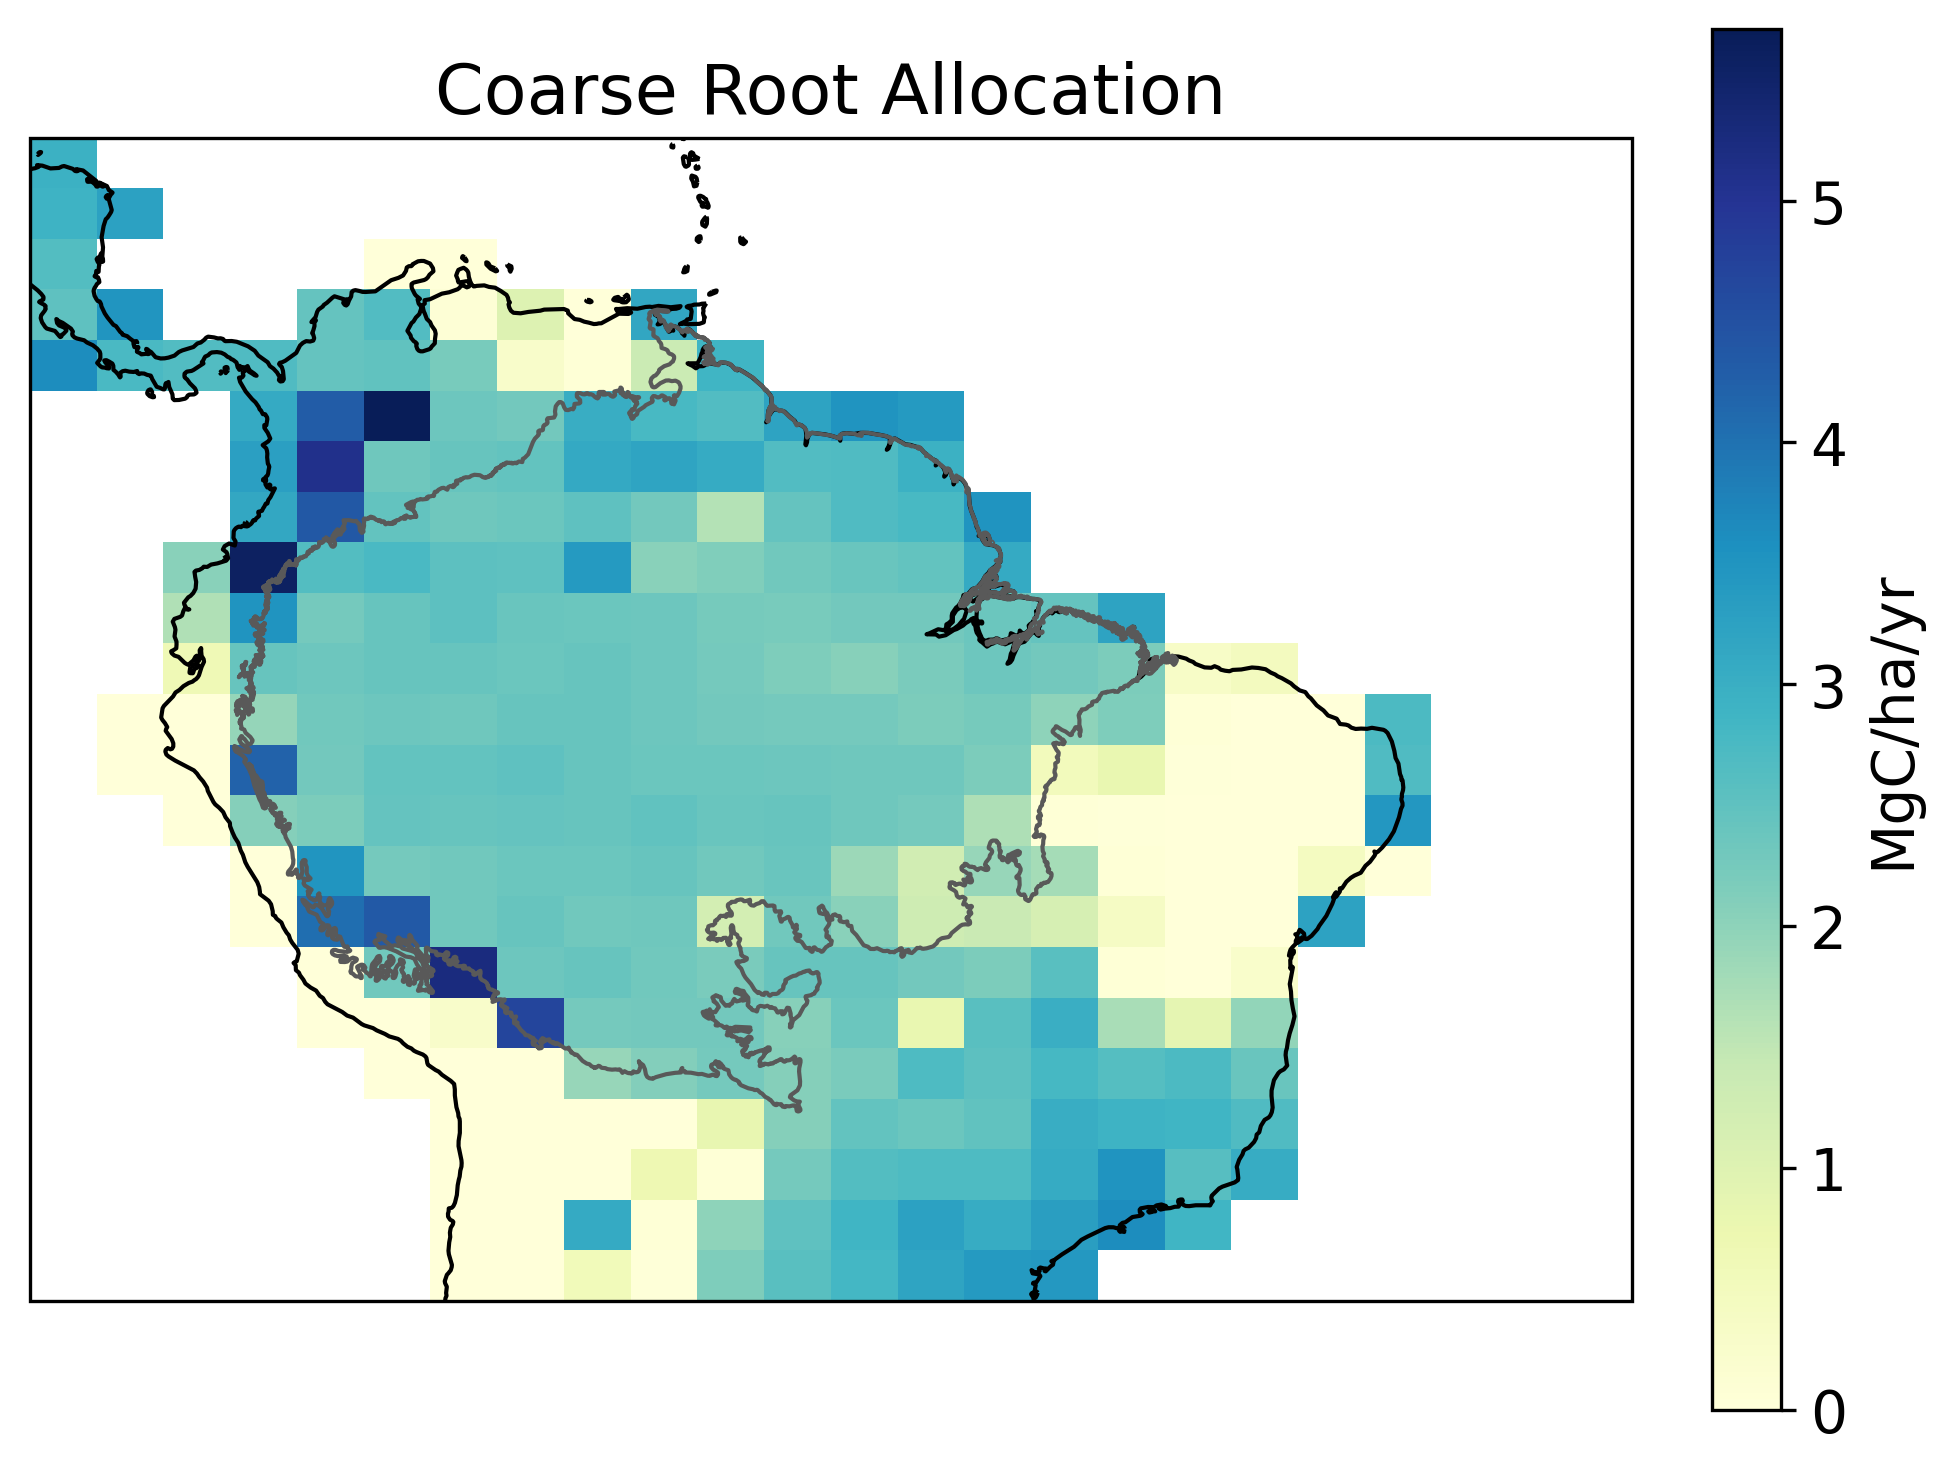

In [32]:
ax = plt.subplot(projection=ccrs.PlateCarree())
(conversion_factor*d0.FATES_CROOT_ALLOC.mean(dim='time')).plot(x='lon', y='lat',cmap=plt.cm.YlGnBu,transform=ccrs.PlateCarree(),cbar_kwargs=dict(location='right',orientation='vertical',label='MgC/ha/yr'))
plt.title('Coarse Root Allocation')
ax.coastlines()
ax.add_geometries(Reader(Amazon_shapefile).geometries(),ccrs.PlateCarree(),edgecolor=(0.35,0.35,0.35,1),facecolor=(0,0,0,0))


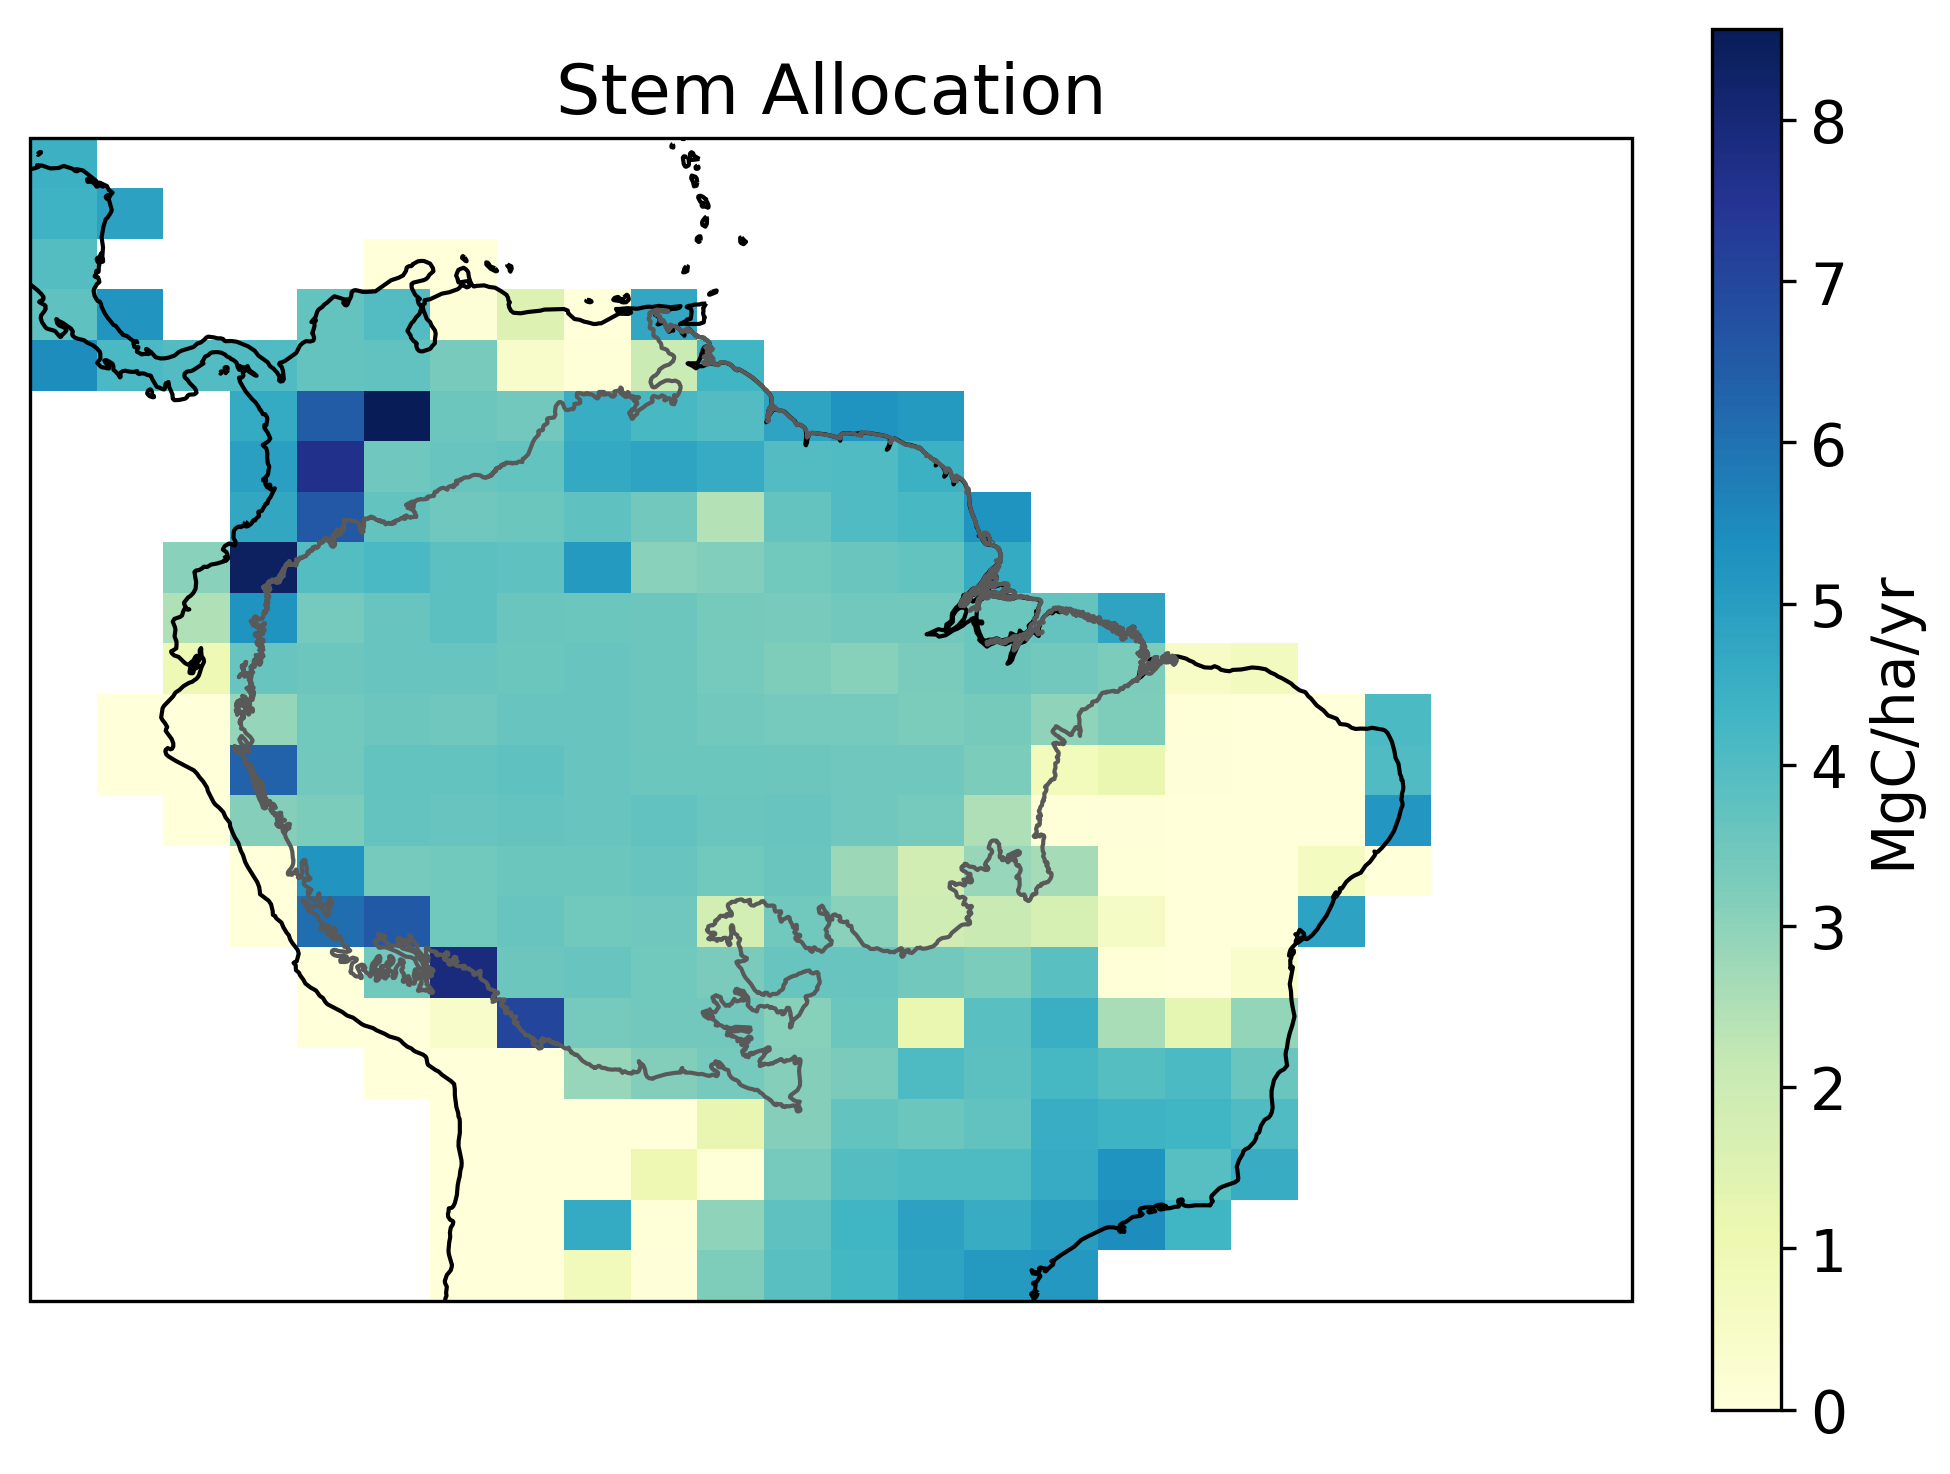

In [33]:
ax = plt.subplot(projection=ccrs.PlateCarree())
(conversion_factor*d0.FATES_STEM_ALLOC.mean(dim='time')).plot(x='lon', y='lat',cmap=plt.cm.YlGnBu,transform=ccrs.PlateCarree(),cbar_kwargs=dict(location='right',orientation='vertical',label='MgC/ha/yr'))
plt.title('Stem Allocation')
ax.coastlines()
ax.add_geometries(Reader(Amazon_shapefile).geometries(),ccrs.PlateCarree(),edgecolor=(0.35,0.35,0.35,1),facecolor=(0,0,0,0))


In [34]:
test=d0.FATES_CROOT_ALLOC.mean(dim='time')/d0.FATES_STEM_ALLOC.mean(dim='time')

In [35]:
np.nanmax(test)

0.66666764

In [36]:
np.nanmin(test)

0.66666603